# Panel design-space presentation: twenty pMHC-TCR structures, T=0.1

This notebook is about the **designs themselves**, not recovery of the native peptide -- no comparison
against the crystal's own peptide appears anywhere below. Same 20-structure panel, 4 models
(ProteinMPNN, ProteinMPNN (no MHC), ESM-IF1, LigandMPNN), 2 conditions (full = MHC+TCR, mhconly =
MHC only), T=0.1.

1. Design counts: total vs. unique, unique by PDB/model, unique-per-model summary with spread
2. Sequence logos of the designs themselves, pooled by length, per model -- full context
3. Same, mhconly (no TCR)
4. Design diversity vs. crystallographic quality (B-factor, resolution)
5. Design diversity vs. peptide-contact structure (contact count, contact distance)
6. Design score distributions, full vs. mhconly
7. Per-position B-factor vs. per-position design diversity (amino-acid entropy)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import logomaker
from pathlib import Path
from scipy.stats import pearsonr, mannwhitneyu, wilcoxon

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel2_design_presentation"
FIG_DIR.mkdir(exist_ok=True, parents=True)
AA = list("ACDEFGHIKLMNPQRSTVWY")
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
# Every (structure, arm, model) cell is truncated to the same number of designs. The raw
# counts differ slightly by generator (9,984 / 10,000 / 10,016), and unique-design counts
# scale with sample size, so comparisons across cells need a common N. 9,984 is the largest
# N every cell can supply; designs are i.i.d. draws, so a prefix is a valid subsample.
N_DESIGNS = 9984
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
CONDITIONS = ["full", "mhconly"]
COND_LABEL = {"full": "pMHC+TCR", "mhconly": "pMHC only"}
STRUCTS = ["2P5W", "1QSF", "1QRN", "2BNR", "2GJ6", "2F53", "2F54", "3QDG", "3QEQ", "3QFJ", "3GSN",
           "1OGA", "3UTS", "5C0A", "5C0B", "5HHO", "5EU6", "2VLR", "4MJI", "5NME",
           "1BD2", "1LP9", "1MI5", "1QSE", "2AK4", "2BNQ", "2E7L", "2J8U", "2JCC", "2OI9",
           "2PYE", "2UWE", "3C60", "3D3V", "3H9S", "3PWP", "3QDJ", "3QIB", "4FTV", "4JFD",
           "4JFE", "4JFF", "4L3E", "4MNQ", "4OZG", "4P23", "4P5T", "5E9D", "6AM5", "6AMU"]

dataset = pd.read_csv(ROOT / "inputs/pmhc_tcr_dataset/dataset.csv")
dataset = dataset[dataset.pdb.isin(STRUCTS)].set_index("pdb").loc[STRUCTS].reset_index()
natives = dict(zip(dataset["pdb"], dataset["peptide"]))
lengths = dict(zip(dataset["pdb"], dataset["pep_len"]))
print(f"{len(dataset)} structures loaded")

50 structures loaded


## Loading designs (peptides only, plus per-design scores where available)

ProteinMPNN (standard and noMHC weights) and LigandMPNN carry a native, comparable per-design score in their FASTA
headers (ProteinMPNN: `score=`, average per-residue negative log-likelihood, lower = higher-confidence;
LigandMPNN: `overall_confidence=`, higher = higher-confidence -- opposite direction and different scale,
so the two are never plotted on one shared axis). ESM-IF1's output header always has `score=nan` in
this campaign, so ESM-IF1 is excluded from every score-distribution comparison below (noted explicitly,
not silently dropped). The first FASTA record in every file is the reference/native entry, not a design,
and is skipped everywhere designs are counted or scored.

In [2]:
def peptide_from_ligandmpnn_line(line):
    return line.strip().split(":")[2]

def load_designs(pdb, cond, length):
    # returns DataFrame with columns: peptide, model, score (NaN if unavailable/not comparable)
    rows = []
    for weights, fname in [("vanilla", f"vanilla_{pdb}.fa"), ("noMHC", f"nomhc_{pdb}.fa")]:
        path = ROOT / f"outputs/panel/{pdb}/{cond}/mpnn/seqs/{fname}"
        lines = path.read_text().splitlines() if path.exists() else []
        lines = lines[:2 * N_DESIGNS + 2]   # uniform sample size across every cell
        for i in range(2, len(lines) - 1, 2):  # skip the first (reference) record
            if lines[i].startswith(">"):
                header, seq = lines[i], lines[i + 1].strip()
                score = np.nan
                for tok in header.split(","):
                    tok = tok.strip()
                    if tok.startswith("score="):
                        score = float(tok.split("=")[1])
                if len(seq) == length:
                    rows.append({"peptide": seq, "model": weights, "score": score})

    path = ROOT / f"outputs/panel/{pdb}/{cond}/esmif/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 0]   # uniform sample size across every cell
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = lines[i + 1].strip()
            if len(seq) == length:
                rows.append({"peptide": seq, "model": "ESM-IF1", "score": np.nan})

    path = ROOT / f"outputs/panel/{pdb}/{cond}/ligandmpnn/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 2]   # uniform sample size across every cell
    for i in range(2, len(lines) - 1, 2):  # skip the first (reference) record
        if lines[i].startswith(">"):
            header, seq = lines[i], peptide_from_ligandmpnn_line(lines[i + 1])
            score = np.nan
            for tok in header.split(","):
                tok = tok.strip()
                if tok.startswith("overall_confidence="):
                    score = float(tok.split("=")[1])
            if len(seq) == length:
                rows.append({"peptide": seq, "model": "LigandMPNN", "score": score})
    return pd.DataFrame(rows)

designs = {}
for pdb in STRUCTS:
    for cond in CONDITIONS:
        designs[(pdb, cond)] = load_designs(pdb, cond, int(lengths[pdb]))
        print(f"{pdb}/{cond}: {len(designs[(pdb, cond)]):,} raw design rows", end="\r")
print("\nall designs loaded")

6AMU/mhconly: 39,936 raw design rows
all designs loaded


## 1. Design counts

### 1a. Total designs vs. unique designs, per PDB, per model (light = total, dark = unique)

  pMHC+TCR mean unique designs per structure: ProteinMPNN 89, ProteinMPNN (no MHC) 105, ESM-IF1 48, LigandMPNN 72  | overall 79 (0.81% of draws)


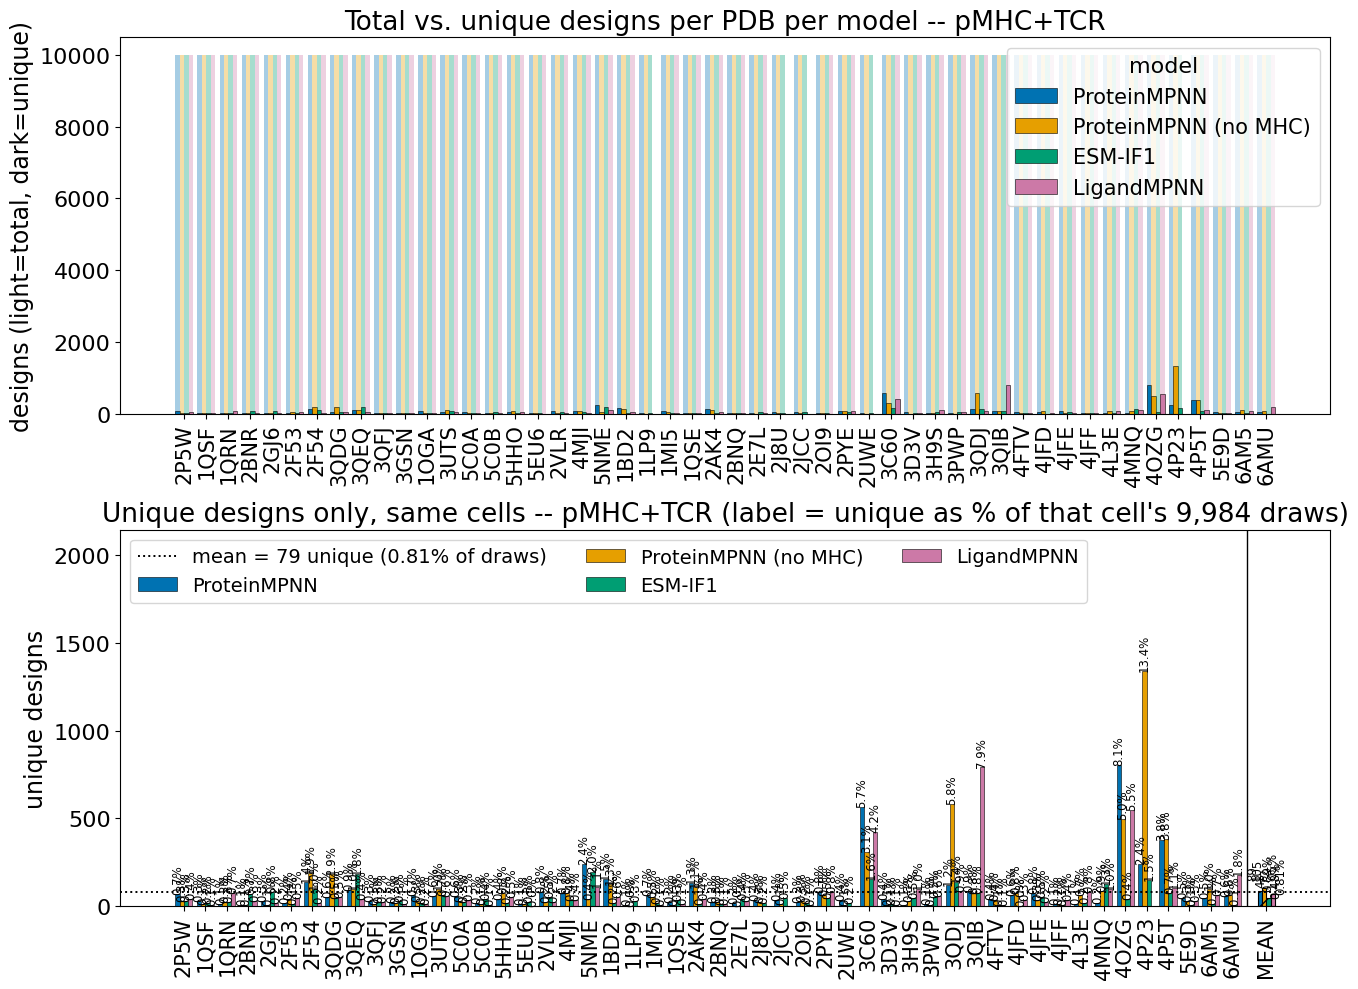

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_total_vs_unique_full.png


  pMHC only mean unique designs per structure: ProteinMPNN 203, ProteinMPNN (no MHC) 184, ESM-IF1 86, LigandMPNN 125  | overall 150 (1.51% of draws)


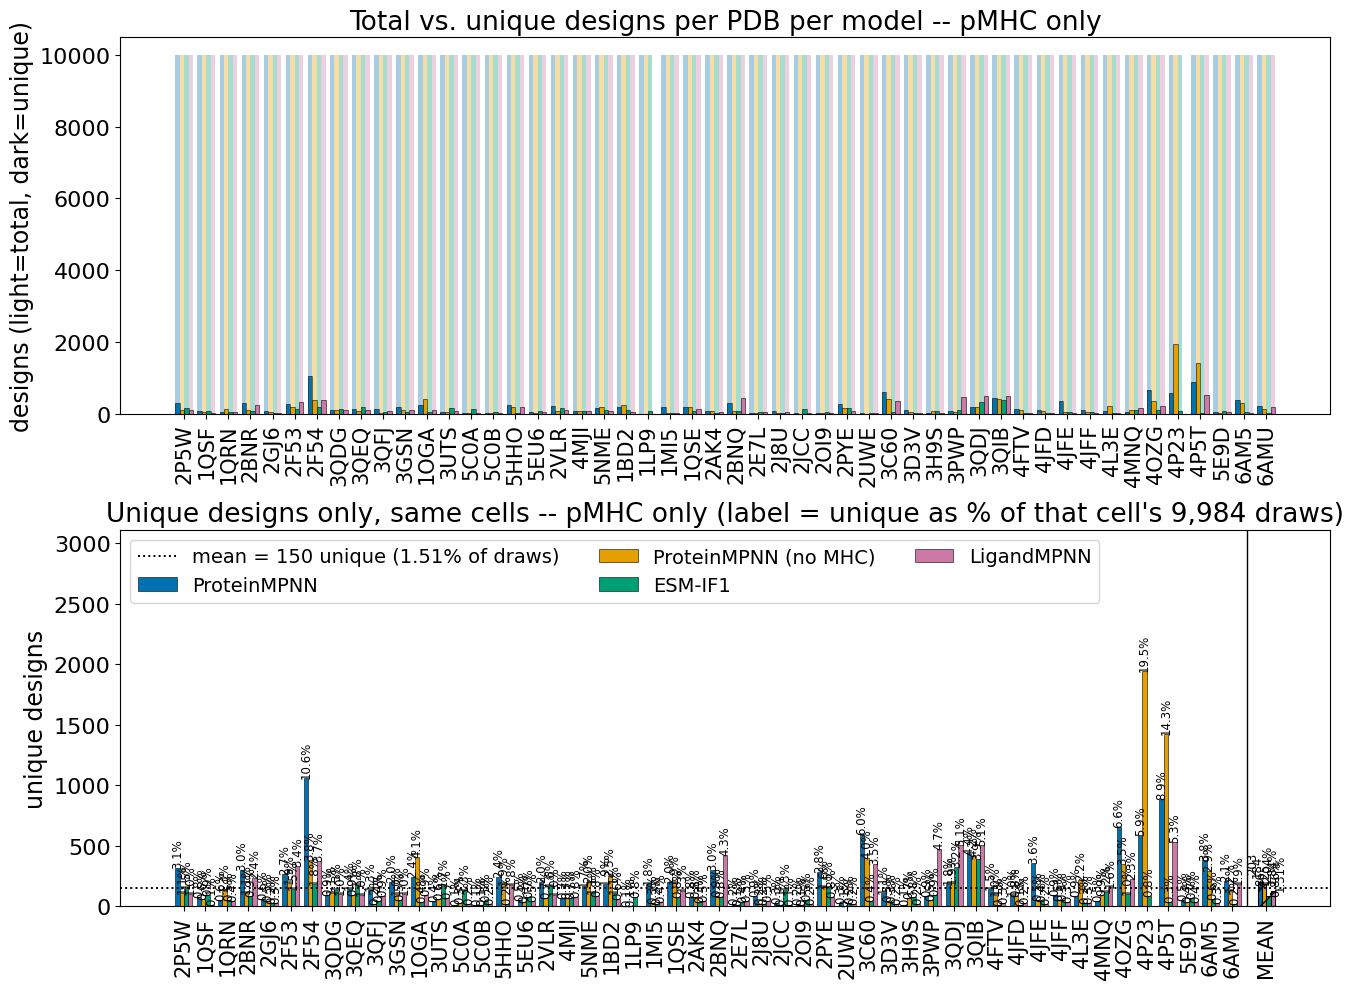

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_total_vs_unique_mhconly.png


In [3]:
count_records = []
for pdb in STRUCTS:
    for cond in CONDITIONS:
        df = designs[(pdb, cond)]
        for model in MODELS:
            sub = df[df.model == model]
            count_records.append({"pdb": pdb, "condition": cond, "model": model,
                                  "total": len(sub), "unique": sub["peptide"].nunique()})
count_df = pd.DataFrame(count_records)
count_df.to_csv(ROOT / "outputs/analysis/panel_design_counts.csv", index=False)

for cond in CONDITIONS:
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13.5, 10))
    sub = count_df[count_df.condition == cond]
    x = np.arange(len(STRUCTS))
    width = 0.2
    for j, model in enumerate(MODELS):
        m = sub[sub.model == model].set_index("pdb").loc[STRUCTS]
        xpos = x + (j - 1.5) * width
        ax.bar(xpos, m["total"], width=width, color=MODEL_COLOR[model], alpha=0.35, edgecolor="none")
        ax.bar(xpos, m["unique"], width=width, color=MODEL_COLOR[model], alpha=1.0, edgecolor="black",
               linewidth=0.4, label=MODEL_LABEL[model] if cond == "full" else None)
    ax.set_xticks(x); ax.set_xticklabels(STRUCTS, rotation=90, fontsize=15)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylabel("designs (light=total, dark=unique)", fontsize=17)
    ax.set_title(f"Total vs. unique designs per PDB per model -- {COND_LABEL[cond]}", fontsize=19)
    if cond == "full":
        ax.legend(title="model", fontsize=15, title_fontsize=16)

    # complement panel: unique designs only. Against a 9,984-draw total the unique bars above
    # are invisible, which is the point being made, but it leaves them unreadable -- here they
    # are on their own scale, each labelled with unique as a percentage of that cell's draws.
    for j, model in enumerate(MODELS):
        m = sub[sub.model == model].set_index("pdb").loc[STRUCTS]
        xpos = x + (j - 1.5) * width
        bars = ax2.bar(xpos, m["unique"], width=width, color=MODEL_COLOR[model],
                       edgecolor="black", linewidth=0.4, label=MODEL_LABEL[model])
        pct = 100 * m["unique"] / m["total"].replace(0, np.nan)
        for b, v in zip(bars, pct):
            if np.isfinite(v):
                ax2.annotate(f"{v:.1f}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                             ha="center", va="bottom", fontsize=8.5, rotation=90)
    mean_unique = sub["unique"].mean()
    mean_pct = 100 * sub["unique"].sum() / sub["total"].sum()
    ax2.axhline(mean_unique, ls=":", lw=1.4, color="black",
                label=f"mean = {mean_unique:.0f} unique ({mean_pct:.2f}% of draws)")

    # a MEAN group at the right end: one bar per model, averaged over structures. The dotted line
    # gives the overall average, but per-model averages are what the text quotes.
    xm = len(STRUCTS) + 0.6
    ax2.axvline(len(STRUCTS) - 0.3, color="black", lw=1.0)
    for j, model in enumerate(MODELS):
        mu = sub.loc[sub.model == model, "unique"].mean()
        tot = sub.loc[sub.model == model, "total"].mean()
        b = ax2.bar(xm + (j - 1.5) * width, mu, width, color=MODEL_COLOR[model],
                    edgecolor="black", linewidth=0.8, hatch="//")
        ax2.annotate(f"{mu:.0f}\n{100 * mu / tot:.2f}%",
                     (b[0].get_x() + b[0].get_width() / 2, b[0].get_height()),
                     ha="center", va="bottom", fontsize=8.5, rotation=90)
    print(f"  {COND_LABEL[cond]} mean unique designs per structure: "
          + ", ".join(f"{MODEL_LABEL[m]} {sub.loc[sub.model == m, 'unique'].mean():.0f}"
                      for m in MODELS)
          + f"  | overall {mean_unique:.0f} ({mean_pct:.2f}% of draws)")

    ax2.set_xticks(list(x) + [xm])
    ax2.set_xticklabels(STRUCTS + ["MEAN"], rotation=90, fontsize=15)
    ax2.tick_params(axis="y", labelsize=16)
    ax2.set_ylabel("unique designs", fontsize=17)
    ax2.set_ylim(0, sub["unique"].max() * 1.6)   # headroom for the rotated % labels
    ax2.set_title(f"Unique designs only, same cells -- {COND_LABEL[cond]} "
                  f"(label = unique as % of that cell's {int(sub['total'].max()):,} draws)",
                  fontsize=19)
    ax2.legend(fontsize=14, ncol=3)
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel2_total_vs_unique_{cond}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

### 1b. Unique designs, aggregated across PDBs and across models

/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname W identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname W identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/tmp/ipykernel_94818/3240257411.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(STRUCTS, rotation=45, ha="right")


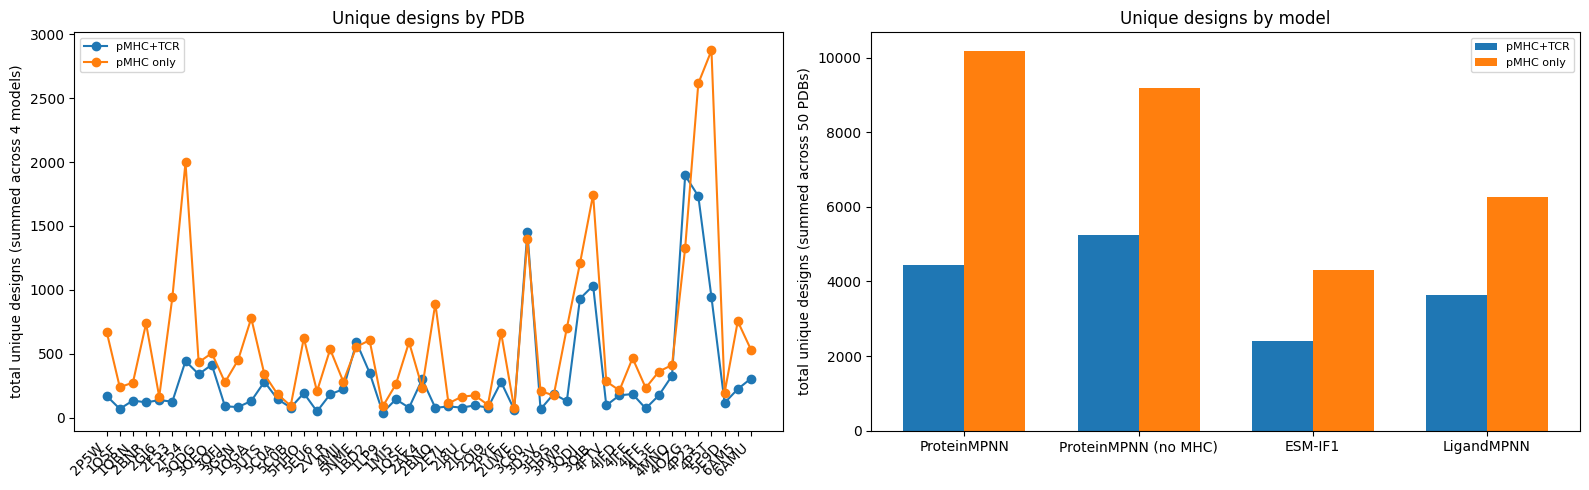

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_unique_by_pdb_and_model.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for cond in CONDITIONS:
    sub = count_df[count_df.condition == cond]
    by_pdb = sub.groupby("pdb")["unique"].sum().loc[STRUCTS]
    by_model = sub.groupby("model")["unique"].sum().loc[MODELS]
    axes[0].plot(STRUCTS, by_pdb.values, marker="o", label=COND_LABEL[cond])
    axes[1].bar(np.arange(len(MODELS)) + (0 if cond == "full" else 0.35), by_model.values, width=0.35,
                label=COND_LABEL[cond])
axes[0].set_xticklabels(STRUCTS, rotation=45, ha="right")
axes[0].set_ylabel("total unique designs (summed across 4 models)")
axes[0].set_title("Unique designs by PDB")
axes[0].legend(fontsize=8)
axes[1].set_xticks(np.arange(len(MODELS)) + 0.175)
axes[1].set_xticklabels([MODEL_LABEL[m] for m in MODELS])
axes[1].set_ylabel(f"total unique designs (summed across {len(STRUCTS)} PDBs)")
axes[1].set_title("Unique designs by model")
axes[1].legend(fontsize=8)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_unique_by_pdb_and_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### 1c. Unique designs per model, mean $\pm$ SD across PDBs, individual PDBs shown as points

Bracket above each model gives a paired Wilcoxon signed-rank test (pMHC+TCR vs. pMHC only, matched by
PDB, $n=20$) on that model's unique-design count -- is the shift in diversity between conditions
significant for that model specifically?

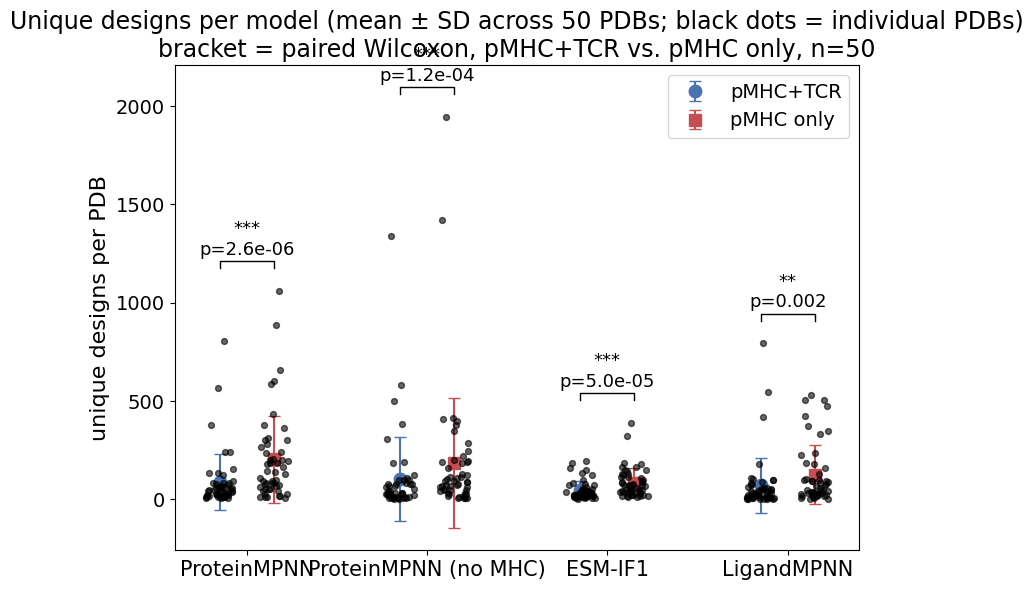

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_unique_per_model_meanstd.png


In [5]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.RandomState(0)
all_vals_by_model = {model: [] for model in MODELS}
for cond, marker in [("full", "o"), ("mhconly", "s")]:
    sub = count_df[count_df.condition == cond]
    means, stds = [], []
    for j, model in enumerate(MODELS):
        vals = sub[sub.model == model].set_index("pdb").loc[STRUCTS, "unique"].values
        means.append(vals.mean()); stds.append(vals.std())
        all_vals_by_model[model].extend(vals.tolist())
        xs = j + (rng.uniform(-0.08, 0.08, size=len(vals)) if cond == "full" else
                  rng.uniform(-0.08, 0.08, size=len(vals)) + 0.3)
        ax.scatter(xs, vals, color="black", s=18, alpha=0.6, zorder=3)
    xpos = np.arange(len(MODELS)) + (0 if cond == "full" else 0.3)
    ax.errorbar(xpos, means, yerr=stds, fmt=marker, markersize=9, capsize=4, label=COND_LABEL[cond],
                color="#4C72B0" if cond == "full" else "#C44E52")

y_top = max(v for vals in all_vals_by_model.values() for v in vals)
bracket_h = y_top * 0.06
for j, model in enumerate(MODELS):
    vals_full = count_df[(count_df.condition == "full") & (count_df.model == model)].set_index(
        "pdb").loc[STRUCTS, "unique"].values
    vals_mhconly = count_df[(count_df.condition == "mhconly") & (count_df.model == model)].set_index(
        "pdb").loc[STRUCTS, "unique"].values
    stat, p = wilcoxon(vals_full, vals_mhconly)
    y = max(vals_full.max(), vals_mhconly.max()) + bracket_h
    x1, x2 = j, j + 0.3
    ax.plot([x1, x1, x2, x2], [y, y + bracket_h * 0.3, y + bracket_h * 0.3, y], color="black",
            linewidth=1)
    p_txt = f"p={p:.3f}" if p >= 1e-3 else f"p={p:.1e}"   # 0.000 tells the reader nothing
    ax.text((x1 + x2) / 2, y + bracket_h * 0.4, f"{sig_stars(p)}\n{p_txt}", ha="center", va="bottom",
            fontsize=13)

ax.set_xticks(np.arange(len(MODELS)) + 0.15)
ax.set_xticklabels([MODEL_LABEL[m] for m in MODELS], fontsize=15)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylabel("unique designs per PDB", fontsize=16)
ax.set_title(f"Unique designs per model (mean ± SD across {len(STRUCTS)} PDBs; "
             f"black dots = individual PDBs)\nbracket = paired Wilcoxon, "
             f"pMHC+TCR vs. pMHC only, n={len(STRUCTS)}", fontsize=17)
ax.legend(fontsize=14)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_unique_per_model_meanstd.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 2. Sequence logos of the designs themselves -- pMHC+TCR

Pooling every unique design from every model together, by length, is not useful (it would mix four
very different design distributions); instead each model gets its own logo, built from that model's
unique designs pooled across every PDB of a given peptide length.

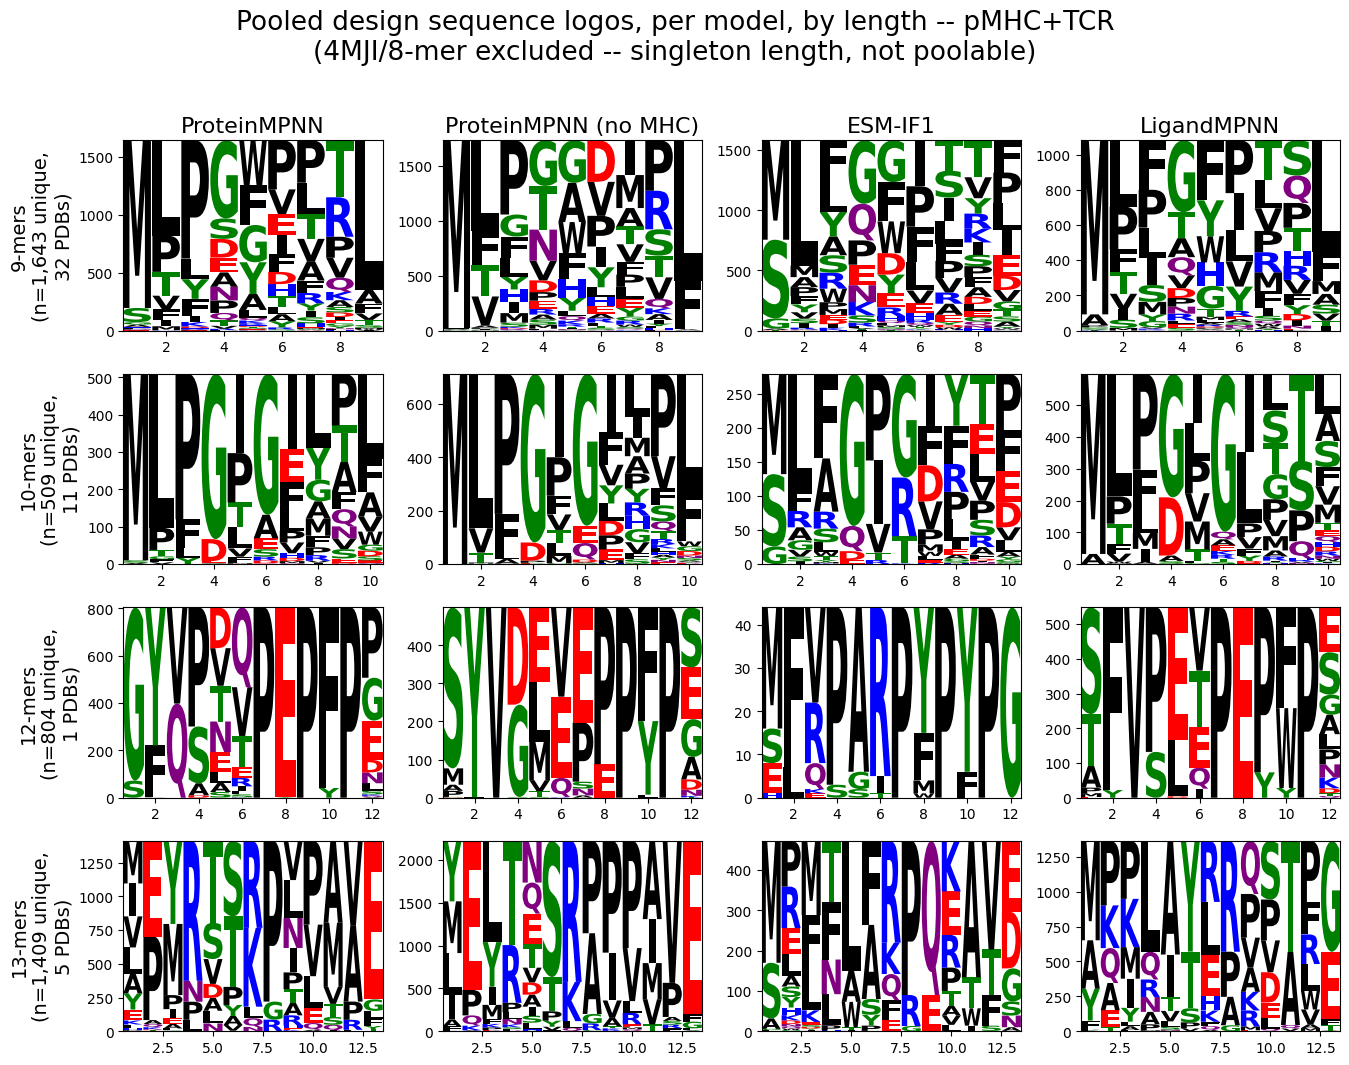

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logos_full.png


In [6]:
def pooled_design_logo_grid(cond, filename, suptitle):
    by_length = {}
    for pdb in STRUCTS:
        if pdb == "4MJI":  # 8-mer, singleton length -- shown separately below
            continue
        by_length.setdefault(int(lengths[pdb]), []).append(pdb)

    fig, axes = plt.subplots(len(by_length), len(MODELS), figsize=(3.4 * len(MODELS), 2.6 * len(by_length)))
    if len(by_length) == 1:
        axes = axes.reshape(1, -1)
    for row, length in enumerate(sorted(by_length)):
        pdbs_this_len = by_length[length]
        for col, model in enumerate(MODELS):
            ax = axes[row, col]
            all_peps = []
            for pdb in pdbs_this_len:
                df = designs[(pdb, cond)]
                all_peps.extend(df.loc[df.model == model, "peptide"].unique().tolist())
            mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
            for pep in all_peps:
                for pos, aa in enumerate(pep, start=1):
                    if aa in AA:
                        mat.loc[pos, aa] += 1.0
            logomaker.Logo(mat, ax=ax, color_scheme="chemistry")
            if row == 0:
                ax.set_title(MODEL_LABEL[model], fontsize=16)
            if col == 0:
                ax.set_ylabel(f"{length}-mers\n(n={len(all_peps):,} unique,\n{len(pdbs_this_len)} PDBs)",
                              fontsize=14)
    fig.suptitle(suptitle, y=1.02, fontsize=19)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

pooled_design_logo_grid("full", "fig_panel2_design_logos_full.png",
                        "Pooled design sequence logos, per model, by length -- pMHC+TCR\n"
                        "(4MJI/8-mer excluded -- singleton length, not poolable)")

## 3. Sequence logos of the designs themselves -- pMHC only

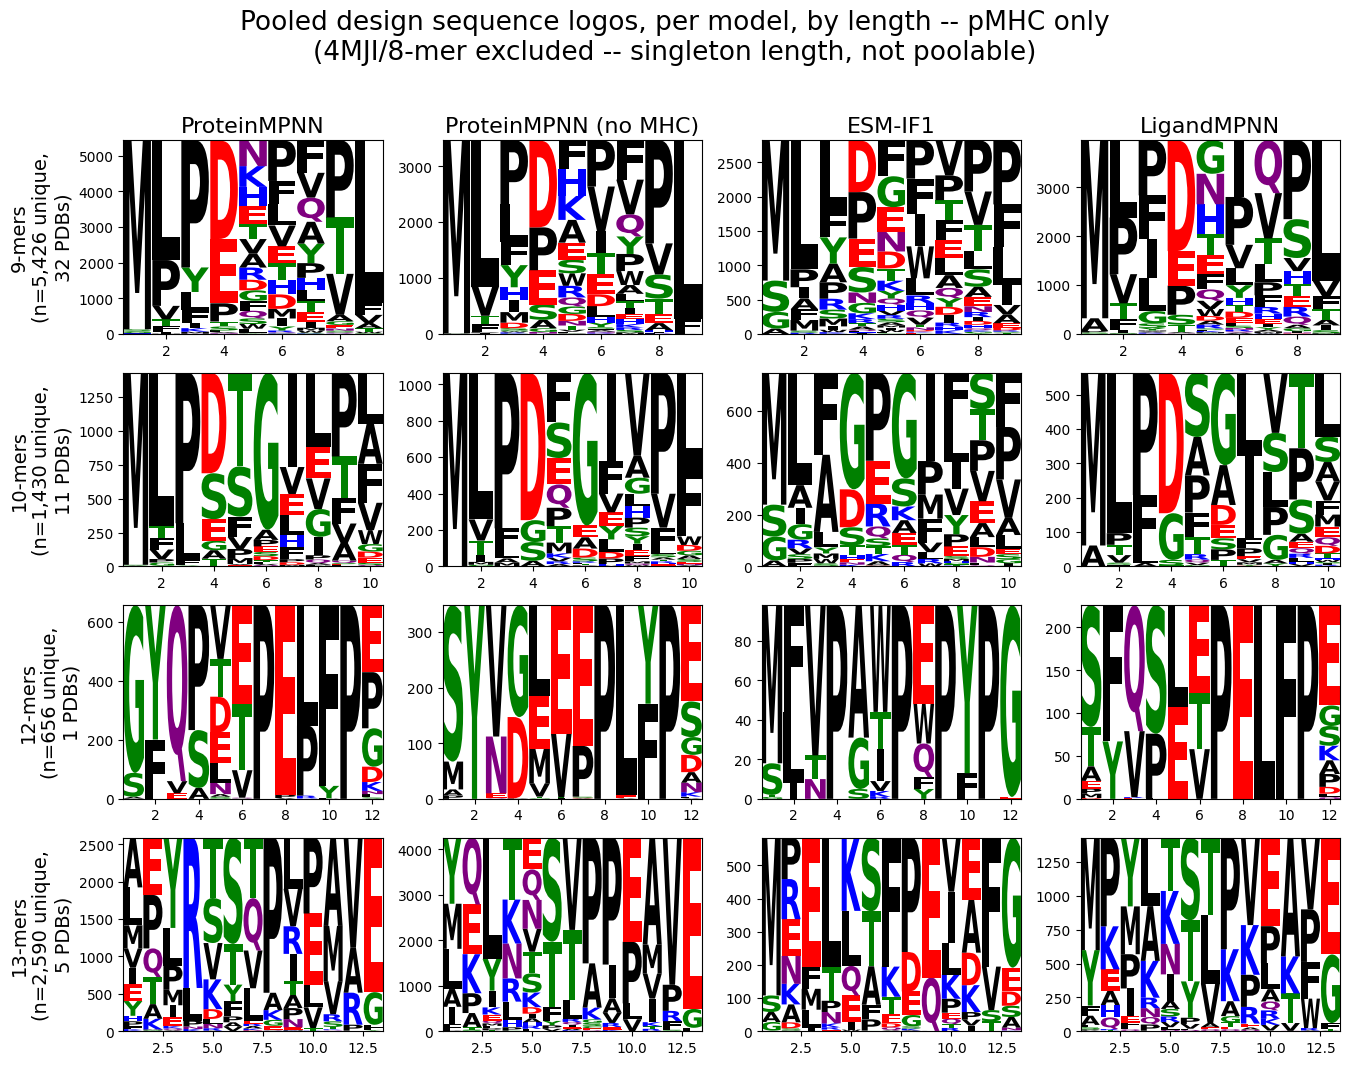

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logos_mhconly.png


In [7]:
pooled_design_logo_grid("mhconly", "fig_panel2_design_logos_mhconly.png",
                        "Pooled design sequence logos, per model, by length -- pMHC only\n"
                        "(4MJI/8-mer excluded -- singleton length, not poolable)")

## 4. Design diversity vs. crystallographic quality

Unique-design count per PDB (summed across the 4 models, both conditions shown) vs. that PDB's own
resolution and mean peptide-chain B-factor (not whole-structure B-factor -- the peptide's own C$\alpha$
B-factor is the more relevant local-order measure here).

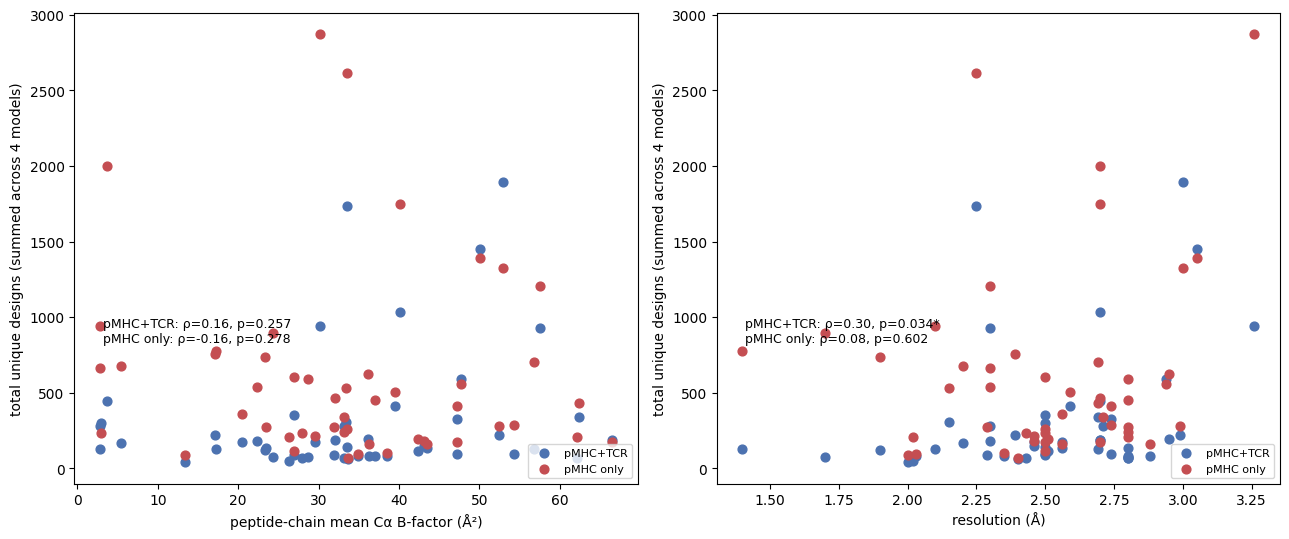

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_vs_quality.png
           rho_bfactor  p_bfactor  rho_resolution  p_resolution
condition                                                      
full          0.163193   0.257478        0.300462      0.033997
mhconly      -0.156354   0.278226        0.075617      0.601726


In [8]:
def peptide_bfactor(pdb):
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    vals, seen = [], set()
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] == "C" and line[12:16].strip() == "CA":
                resnum = line[22:27]
                if resnum in seen:
                    continue
                seen.add(resnum)
                vals.append(float(line[60:66]))
    return float(np.mean(vals))

def parse_resolution(pdb):
    path = ROOT / f"inputs/pmhc_tcr_dataset/{pdb}.pdb"
    with open(path) as f:
        for line in f:
            if line.startswith("REMARK   2 RESOLUTION"):
                try:
                    return float(line.split("RESOLUTION.")[1].split("ANGSTROMS")[0].strip())
                except Exception:
                    return np.nan
    return np.nan

pep_bfactor = {pdb: peptide_bfactor(pdb) for pdb in STRUCTS}
resolution = {pdb: parse_resolution(pdb) for pdb in STRUCTS}

quality_df = count_df.groupby(["pdb", "condition"])["unique"].sum().reset_index()
quality_df["pep_bfactor"] = quality_df["pdb"].map(pep_bfactor)
quality_df["resolution"] = quality_df["pdb"].map(resolution)

from scipy.stats import spearmanr

COND_PLOT_COLOR = {"full": "#4C72B0", "mhconly": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, xcol, xlabel in [(axes[0], "pep_bfactor", "peptide-chain mean Cα B-factor (Å²)"),
                          (axes[1], "resolution", "resolution (Å)")]:
    annot_lines = []
    for cond in CONDITIONS:
        sub = quality_df[quality_df.condition == cond]
        ax.scatter(sub[xcol], sub["unique"], label=COND_LABEL[cond], s=40,
                   color=COND_PLOT_COLOR[cond])
        rho, p = spearmanr(sub[xcol], np.log10(sub["unique"].clip(lower=1)))
        sig = "*" if p < 0.05 else ""
        annot_lines.append(f"{COND_LABEL[cond]}: ρ={rho:.2f}, p={p:.3f}{sig}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("total unique designs (summed across 4 models)")
    for k, text in enumerate(annot_lines):
        ax.text(0.05, 1000 - 100 * k, text, transform=ax.get_yaxis_transform(), ha="left", va="top",
                fontsize=9, color="black")
    ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
out = FIG_DIR / "fig_panel2_diversity_vs_quality.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(quality_df.groupby("condition").apply(
    lambda g: pd.Series({"rho_bfactor": spearmanr(g["pep_bfactor"], np.log10(g["unique"].clip(lower=1)))[0],
                         "p_bfactor": spearmanr(g["pep_bfactor"], np.log10(g["unique"].clip(lower=1)))[1],
                         "rho_resolution": spearmanr(g["resolution"], np.log10(g["unique"].clip(lower=1)))[0],
                         "p_resolution": spearmanr(g["resolution"], np.log10(g["unique"].clip(lower=1)))[1]})))

## 5. Design diversity vs. peptide-contact structure -- per residue

Each point below is a single peptide **residue** (one (PDB, position) pair, not a whole peptide): how
many atoms of that specific residue are within $<5$\AA{} of the TCR or MHC (its own "number of
interactions"), and the Shannon entropy of the amino-acid distribution the model(s) actually produced
at that exact position (entropy, not raw count of distinct amino acids -- entropy also reflects how
*even* the distribution is, so one dominant pick plus a rare outlier no longer looks as diverse as four
roughly equally-used amino acids). pMHC+TCR and pMHC-only are shown as separate panels throughout
rather than overlaid. First per model (4 columns), then with all four models' raw designs pooled into
a single combined distribution per position ("all models combined").

per-model: n=3793 rows; all-models-combined: n=966 rows


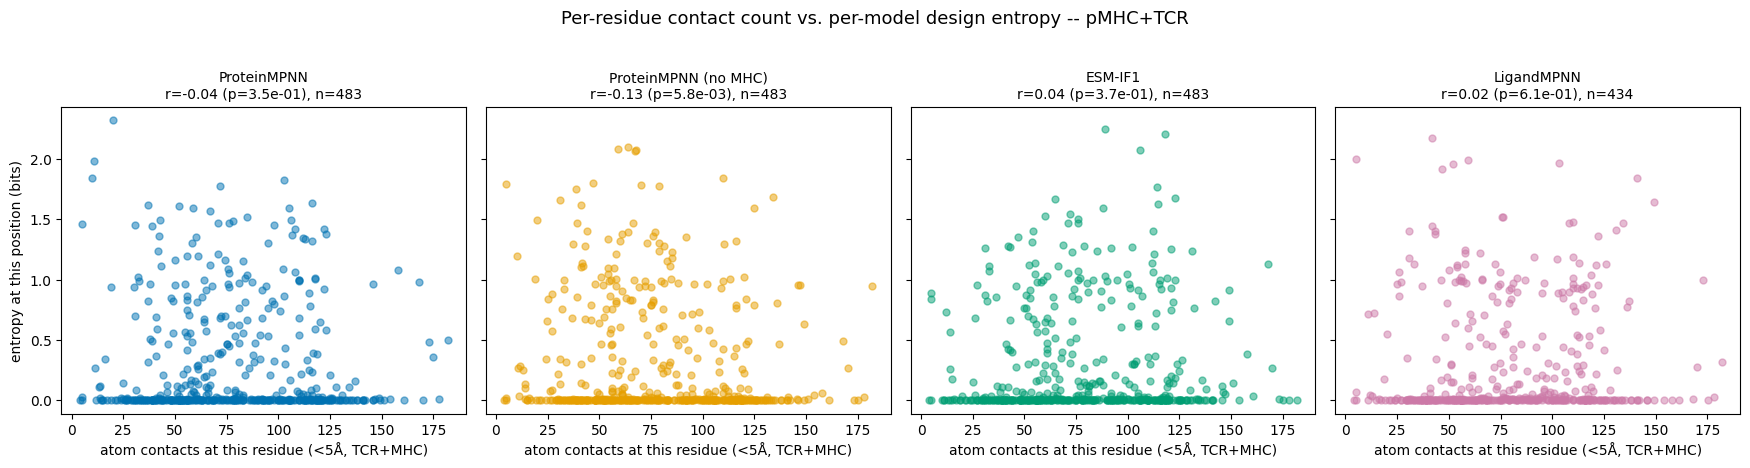

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_by_model_full.png


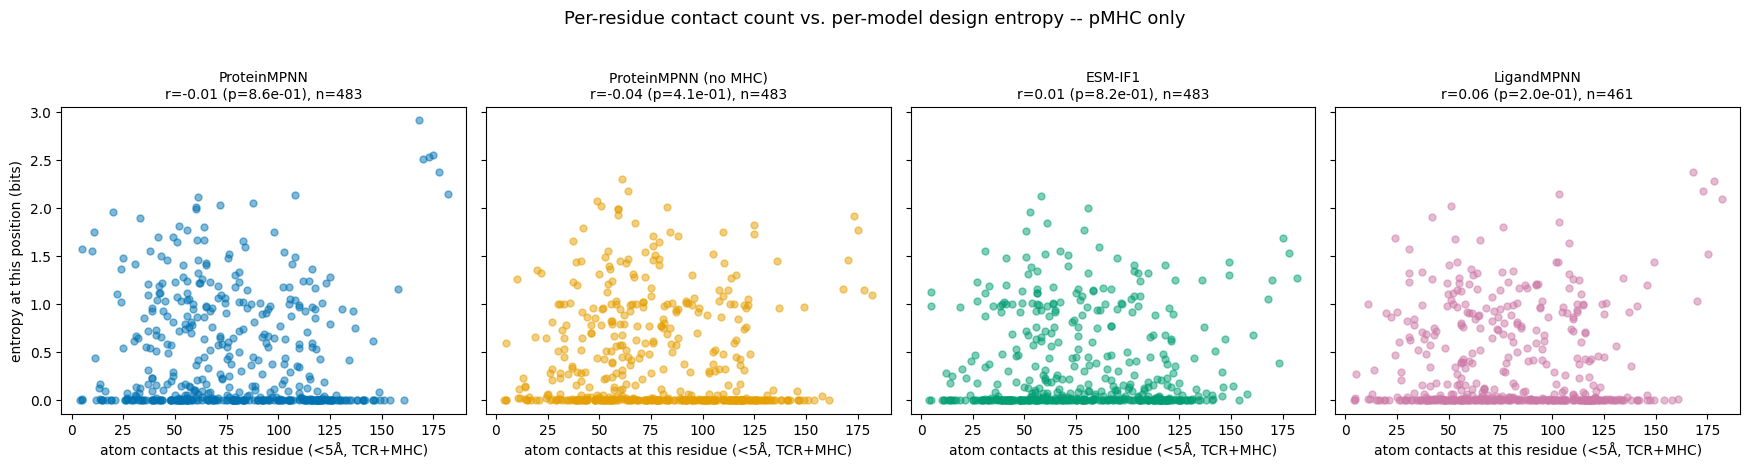

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_by_model_mhconly.png


In [9]:
def parse_atoms_by_residue(path, chains):
    coords = {c: [] for c in chains}
    resnum = {c: [] for c in chains}
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] in chains:
                c = line[21]
                coords[c].append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
                resnum[c].append(line[22:27])
    return ({c: np.array(coords[c]).reshape(-1, 3) for c in chains},
            {c: np.array(resnum[c]) for c in chains})

def per_residue_contacts(pep, pep_res, partner, cutoff=5.0):
    # returns {residue_index (1-based, file order): (n_atom_contacts, min_dist)}
    d = np.linalg.norm(pep[:, None, :] - partner[None, :, :], axis=2)
    within = d < cutoff
    out = {}
    for local_pos, resnum in enumerate(pd.unique(pep_res), start=1):
        mask = pep_res == resnum
        sub_within = within[mask]
        sub_d = d[mask]
        n_atom = int(sub_within.sum())
        min_dist = float(sub_d.min()) if sub_d.size else np.nan
        out[local_pos] = (n_atom, min_dist)
    return out

residue_contact_records = []
for pdb in STRUCTS:
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    coords, resnum = parse_atoms_by_residue(path, ["A", "C", "D", "E"])
    pep, pep_res = coords["C"], resnum["C"]
    tcr = np.vstack([coords["D"], coords["E"]])
    tcr_stats = per_residue_contacts(pep, pep_res, tcr)
    mhc_stats = per_residue_contacts(pep, pep_res, coords["A"])
    for pos in tcr_stats:
        n_tcr, d_tcr = tcr_stats[pos]
        n_mhc, d_mhc = mhc_stats[pos]
        residue_contact_records.append({
            "pdb": pdb, "position": pos,
            "n_atom_contacts_total": n_tcr + n_mhc,
            "min_dist_total": np.nanmin([d_tcr, d_mhc]),
            "n_tcr_contacts": n_tcr, "n_mhc_contacts": n_mhc,
            "min_dist_tcr": d_tcr, "min_dist_mhc": d_mhc,
        })
residue_contact_df = pd.DataFrame(residue_contact_records)

def shannon_entropy(counts):
    counts = np.array(counts, dtype=float)
    counts = counts[counts > 0]
    if counts.sum() == 0:
        return np.nan
    p = counts / counts.sum()
    return -(p * np.log2(p)).sum()

def position_entropy_records(cond, per_model):
    records = []
    for pdb in STRUCTS:
        length = int(lengths[pdb])
        df = designs[(pdb, cond)]
        groups = ({model: df.loc[df.model == model, "peptide"].tolist() for model in MODELS}
                  if per_model else {"ALL": df["peptide"].tolist()})
        for key, peps in groups.items():
            if not peps:
                continue
            for pos in range(length):
                counts = pd.Series([p[pos] for p in peps]).value_counts()
                records.append({"pdb": pdb, "position": pos + 1, "condition": cond, "group": key,
                                "entropy": shannon_entropy(counts.values)})
    return pd.DataFrame(records)

entropy_by_model_df = pd.concat([position_entropy_records(cond, True) for cond in CONDITIONS],
                                ignore_index=True)
entropy_pooled_df = pd.concat([position_entropy_records(cond, False) for cond in CONDITIONS],
                              ignore_index=True)
residue_by_model_df = entropy_by_model_df.merge(residue_contact_df, on=["pdb", "position"])
residue_pooled_df = entropy_pooled_df.merge(residue_contact_df, on=["pdb", "position"])
print(f"per-model: n={len(residue_by_model_df)} rows; all-models-combined: n={len(residue_pooled_df)} rows")

for cond in CONDITIONS:
    fig, axes = plt.subplots(1, 4, figsize=(4.4 * 4, 4.5), sharey=True)
    sub_cond = residue_by_model_df[residue_by_model_df.condition == cond]
    rng = np.random.RandomState(0)
    for ax, model in zip(axes, MODELS):
        sub = sub_cond[sub_cond.group == model]
        jitter = rng.uniform(-0.15, 0.15, size=len(sub))
        ax.scatter(sub["n_atom_contacts_total"] + jitter, sub["entropy"], alpha=0.5, s=25,
                   color=MODEL_COLOR[model])
        r, p = pearsonr(sub["n_atom_contacts_total"], sub["entropy"])
        ax.set_xlabel("atom contacts at this residue (<5Å, TCR+MHC)")
        ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}", fontsize=10)
    axes[0].set_ylabel("entropy at this position (bits)")
    fig.suptitle(f"Per-residue contact count vs. per-model design entropy -- {COND_LABEL[cond]}",
                y=1.03, fontsize=13)
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel2_diversity_entropy_by_model_{cond}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

### All four models' designs pooled together (raw, not deduplicated) into one combined
per-position distribution

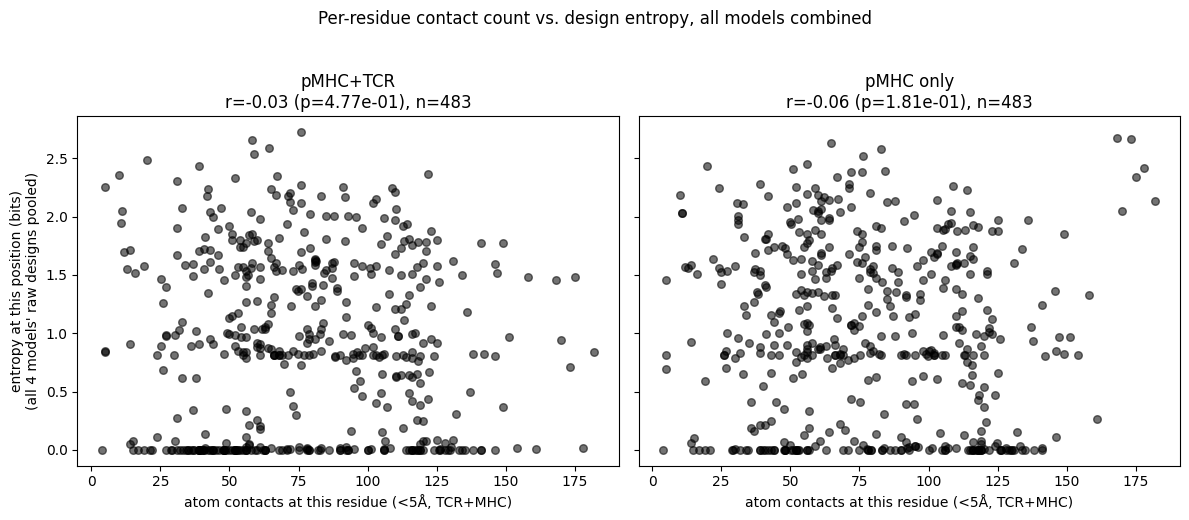

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_pooled.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
rng = np.random.RandomState(0)
for ax, cond in zip(axes, CONDITIONS):
    sub = residue_pooled_df[residue_pooled_df.condition == cond]
    jitter = rng.uniform(-0.15, 0.15, size=len(sub))
    ax.scatter(sub["n_atom_contacts_total"] + jitter, sub["entropy"], alpha=0.55, s=30, color="black")
    r, p = pearsonr(sub["n_atom_contacts_total"], sub["entropy"])
    ax.set_xlabel("atom contacts at this residue (<5Å, TCR+MHC)")
    ax.set_title(f"{COND_LABEL[cond]}\nr={r:.2f} (p={p:.2e}), n={len(sub)}")
axes[0].set_ylabel("entropy at this position (bits)\n(all 4 models' raw designs pooled)")
fig.suptitle("Per-residue contact count vs. design entropy, all models combined", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_diversity_entropy_pooled.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Same two analyses, using the residue's own closest contact distance (Å) instead of atom count

Distance to the nearest TCR/MHC atom, not atom-contact count, as the x-axis -- same per-model (4
columns) and all-models-combined layout as above.

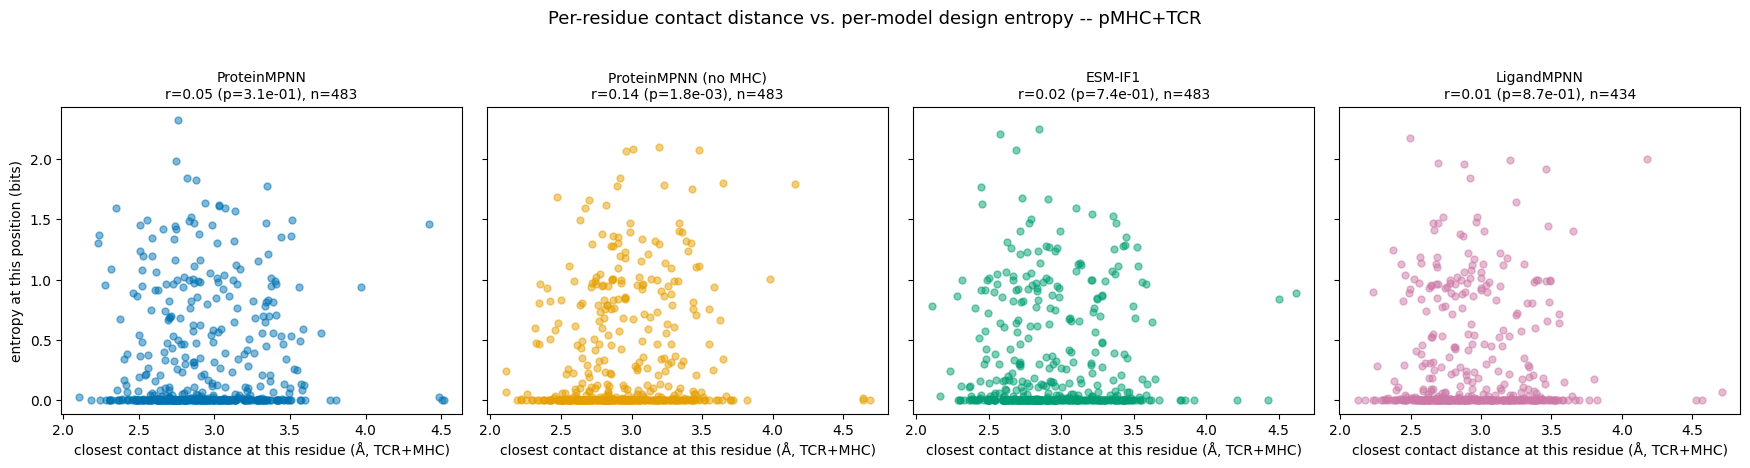

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_by_model_distance_full.png


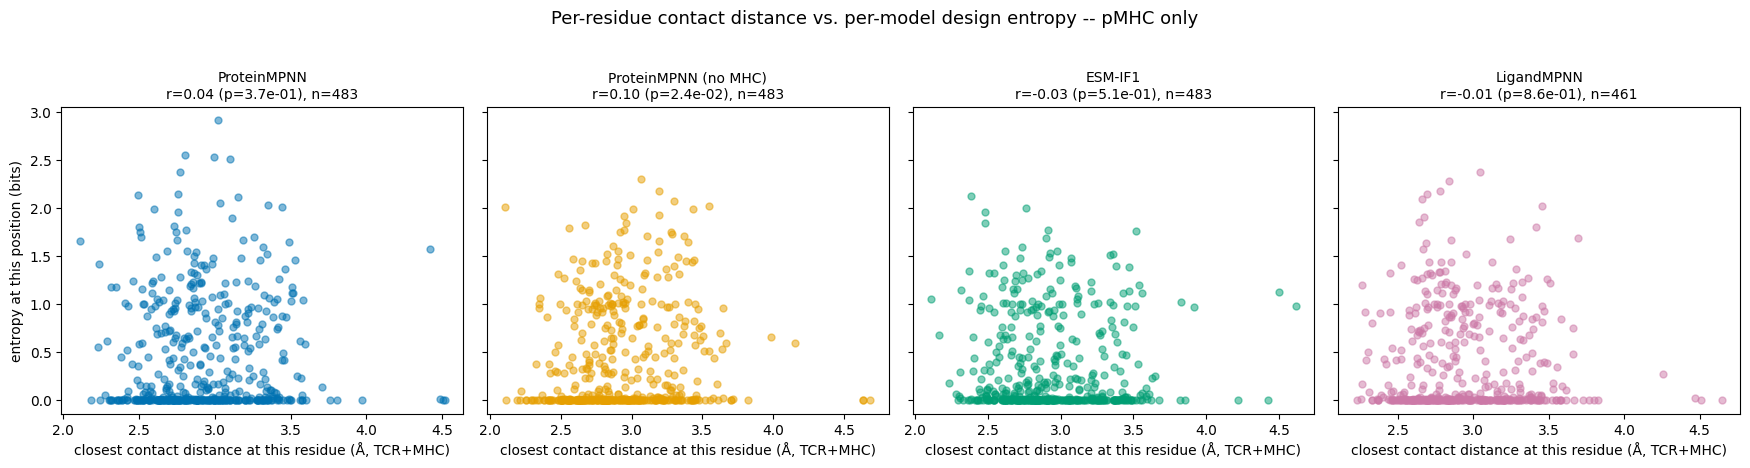

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_by_model_distance_mhconly.png


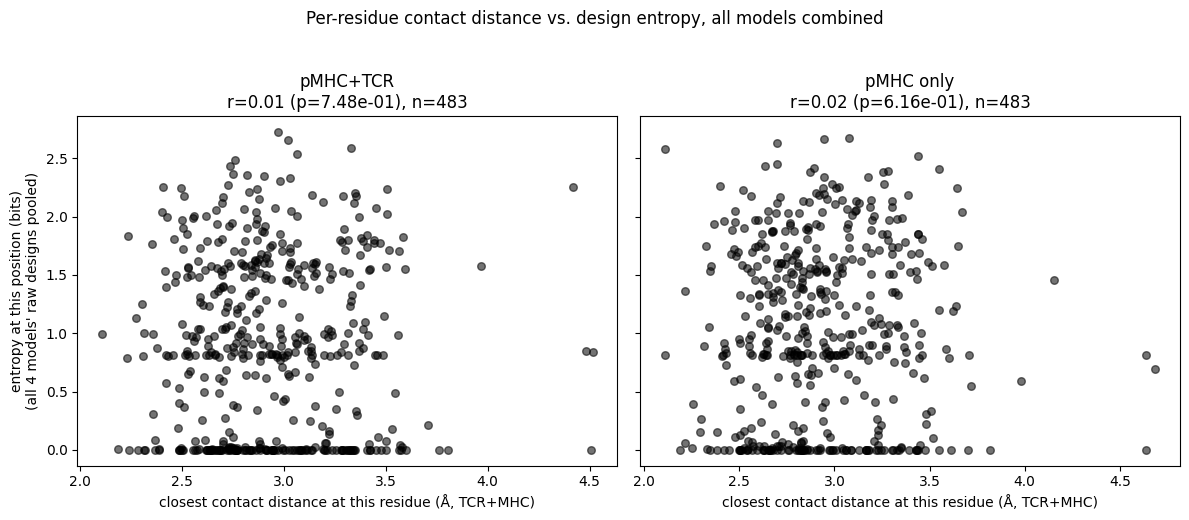

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_pooled_distance.png


In [11]:
for cond in CONDITIONS:
    fig, axes = plt.subplots(1, 4, figsize=(4.4 * 4, 4.5), sharey=True)
    sub_cond = residue_by_model_df[residue_by_model_df.condition == cond]
    rng = np.random.RandomState(0)
    for ax, model in zip(axes, MODELS):
        sub = sub_cond[sub_cond.group == model]
        jitter = rng.uniform(-0.15, 0.15, size=len(sub))
        ax.scatter(sub["min_dist_total"] + jitter, sub["entropy"], alpha=0.5, s=25,
                   color=MODEL_COLOR[model])
        r, p = pearsonr(sub["min_dist_total"], sub["entropy"])
        ax.set_xlabel("closest contact distance at this residue (Å, TCR+MHC)")
        ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}", fontsize=10)
    axes[0].set_ylabel("entropy at this position (bits)")
    fig.suptitle(f"Per-residue contact distance vs. per-model design entropy -- {COND_LABEL[cond]}",
                y=1.03, fontsize=13)
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel2_diversity_entropy_by_model_distance_{cond}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
rng = np.random.RandomState(0)
for ax, cond in zip(axes, CONDITIONS):
    sub = residue_pooled_df[residue_pooled_df.condition == cond]
    jitter = rng.uniform(-0.15, 0.15, size=len(sub))
    ax.scatter(sub["min_dist_total"] + jitter, sub["entropy"], alpha=0.55, s=30, color="black")
    r, p = pearsonr(sub["min_dist_total"], sub["entropy"])
    ax.set_xlabel("closest contact distance at this residue (Å, TCR+MHC)")
    ax.set_title(f"{COND_LABEL[cond]}\nr={r:.2f} (p={p:.2e}), n={len(sub)}")
axes[0].set_ylabel("entropy at this position (bits)\n(all 4 models' raw designs pooled)")
fig.suptitle("Per-residue contact distance vs. design entropy, all models combined", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_diversity_entropy_pooled_distance.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Entropy vs. per-residue C$\alpha$ B-factor, colored by atom-contact count

Crystallographic resolution is a single number for the whole diffraction dataset -- it cannot be
decomposed down to an individual atom, so it's the wrong quantity for a per-residue x-axis (every
position in a structure was artificially tied to the same value in the resolution version of this
plot). The single-atom-level analog of "local structural precision" is the C$\alpha$ B-factor
(temperature factor): each Cα in the crystal has its own, reflecting how well-ordered/rigid the model
found that specific atom to be. Colored by that residue's own atom-contact count so both effects are
visible on one plot.

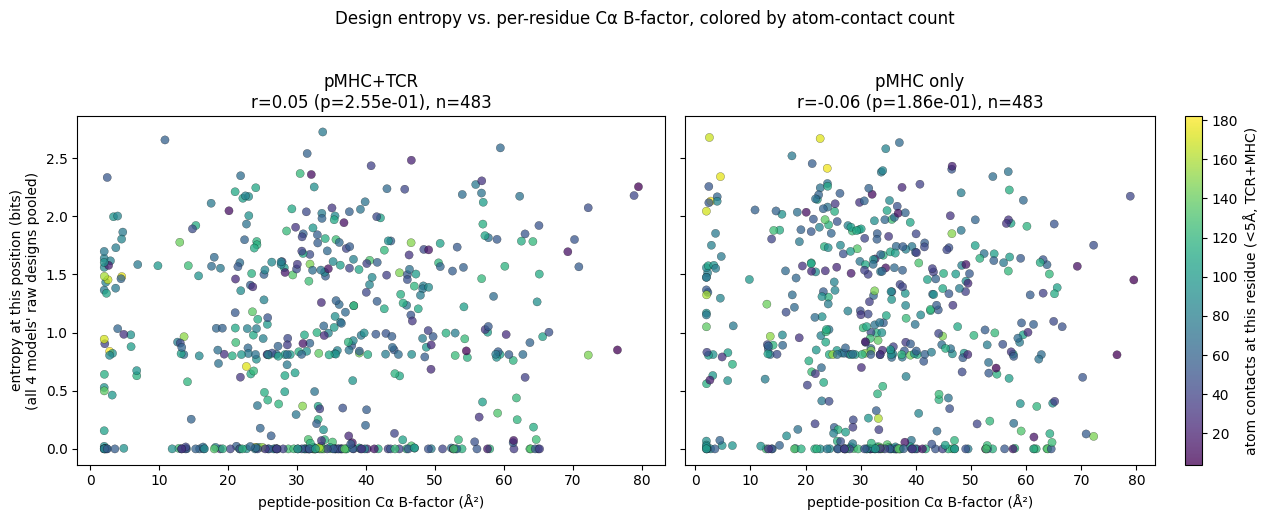

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_vs_bfactor.png


In [12]:
def peptide_bfactor_by_position(pdb):
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    vals, seen = [], set()
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] == "C" and line[12:16].strip() == "CA":
                resnum = line[22:27]
                if resnum in seen:
                    continue
                seen.add(resnum)
                vals.append(float(line[60:66]))
    return vals  # 0-indexed by position

bfac_by_pdb_pos = {}
for pdb in STRUCTS:
    bfac_by_pos = peptide_bfactor_by_position(pdb)
    for pos, bfac in enumerate(bfac_by_pos, start=1):
        bfac_by_pdb_pos[(pdb, pos)] = bfac
residue_pooled_df["ca_bfactor"] = residue_pooled_df.apply(
    lambda row: bfac_by_pdb_pos[(row["pdb"], row["position"])], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    sub = residue_pooled_df[residue_pooled_df.condition == cond]
    sc = ax.scatter(sub["ca_bfactor"], sub["entropy"], c=sub["n_atom_contacts_total"], cmap="viridis",
                    s=35, alpha=0.75, edgecolor="black", linewidth=0.2)
    r, p = pearsonr(sub["ca_bfactor"], sub["entropy"])
    ax.set_xlabel("peptide-position Cα B-factor (Å²)")
    ax.set_title(f"{COND_LABEL[cond]}\nr={r:.2f} (p={p:.2e}), n={len(sub)}")
axes[0].set_ylabel("entropy at this position (bits)\n(all 4 models' raw designs pooled)")
fig.colorbar(sc, ax=axes[1], label="atom contacts at this residue (<5Å, TCR+MHC)")
fig.suptitle("Design entropy vs. per-residue Cα B-factor, colored by atom-contact count", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_diversity_entropy_vs_bfactor.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 6. Design score distributions, full vs. mhconly

ESM-IF1 has no usable score in this campaign (`score=nan` for every design) and is excluded. LigandMPNN's
`overall_confidence` (higher = better) is on a different scale/direction from ProteinMPNN's `score`
(lower = better) and is shown on its own panel, never on a shared axis with the other two.

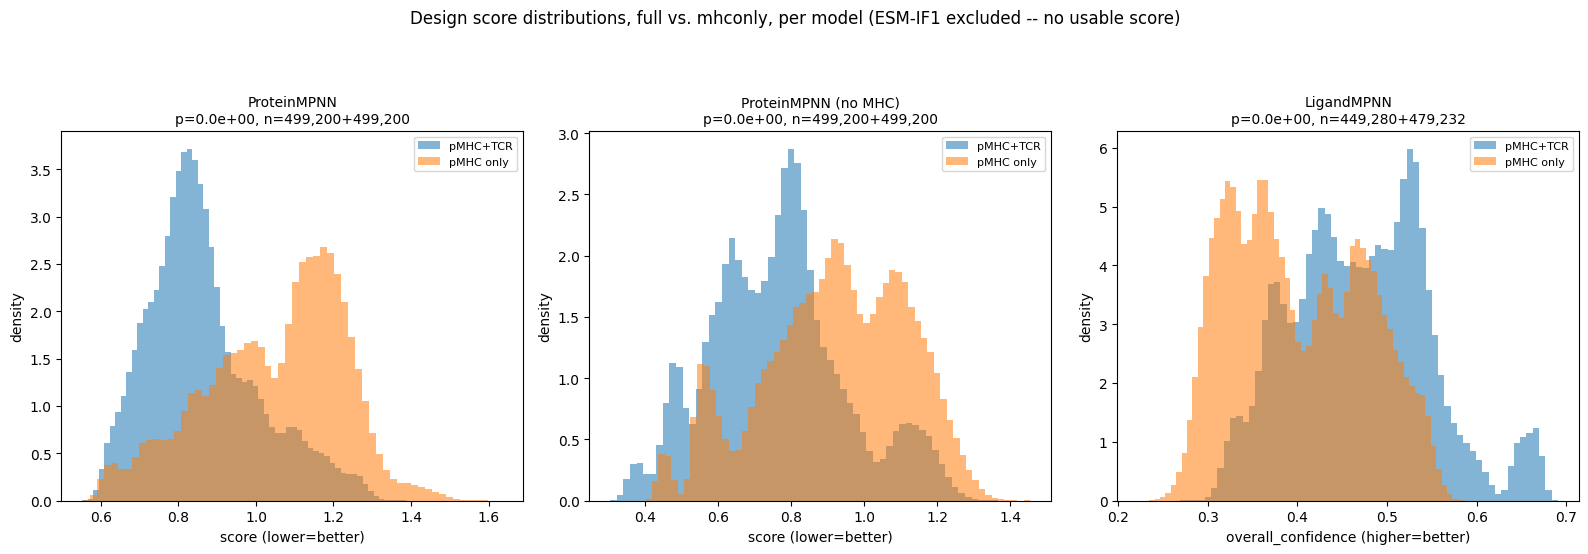

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_score_distributions.png


In [13]:
score_models = ["vanilla", "noMHC", "LigandMPNN"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, model in zip(axes, score_models):
    all_scores = {cond: [] for cond in CONDITIONS}
    for pdb in STRUCTS:
        for cond in CONDITIONS:
            df = designs[(pdb, cond)]
            vals = df.loc[df.model == model, "score"].dropna().values
            all_scores[cond].extend(vals.tolist())
    for cond in CONDITIONS:
        ax.hist(all_scores[cond], bins=60, alpha=0.55, density=True, label=COND_LABEL[cond])
    stat, p = mannwhitneyu(all_scores["full"], all_scores["mhconly"], alternative="two-sided")
    direction = "lower=better" if model != "LigandMPNN" else "higher=better"
    ax.set_xlabel(f"{'score' if model != 'LigandMPNN' else 'overall_confidence'} ({direction})")
    ax.set_ylabel("density")
    ax.set_title(f"{MODEL_LABEL[model]}\np={p:.1e}, n={len(all_scores['full']):,}+{len(all_scores['mhconly']):,}",
                 fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Design score distributions, full vs. mhconly, per model (ESM-IF1 excluded -- no usable score)",
             y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.93])
out = FIG_DIR / "fig_panel2_score_distributions.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### 6b. Score distributions, one row per PDB (does the pooled significance hold per-crystal?)

The pooled test above (n≈200,000) is essentially guaranteed to be significant regardless of effect
size at that sample size -- it doesn't tell us whether the full-vs-mhconly shift is a uniform effect
present in every crystal, or driven by a handful of crystals with a big shift while others show almost
none. One row per PDB, one column per scoreable model (ESM-IF1 still excluded -- no usable score),
full vs. mhconly overlaid per cell, with that cell's own Mann-Whitney p-value.

/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


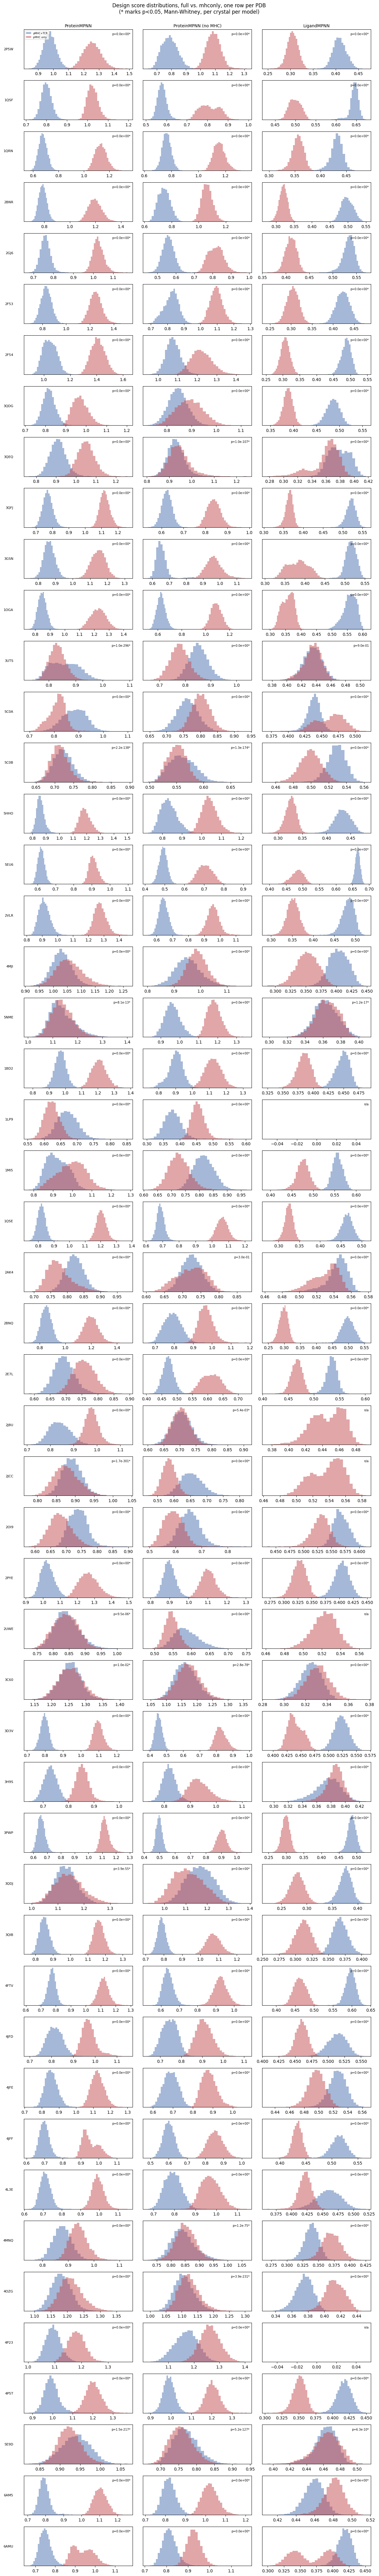

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_score_distributions_by_pdb.png



143/145 (PDB, model) cells reach p<0.05 individually


In [14]:
score_models = ["vanilla", "noMHC", "LigandMPNN"]
fig, axes = plt.subplots(len(STRUCTS), len(score_models),
                         figsize=(4.2 * len(score_models), 1.7 * len(STRUCTS)))
for row, pdb in enumerate(STRUCTS):
    for col, model in enumerate(score_models):
        ax = axes[row, col]
        scores = {}
        for cond in CONDITIONS:
            df = designs[(pdb, cond)]
            scores[cond] = df.loc[df.model == model, "score"].dropna().values
        for cond in CONDITIONS:
            ax.hist(scores[cond], bins=30, alpha=0.5, density=True, color=COND_PLOT_COLOR[cond],
                    label=COND_LABEL[cond])
        if len(scores["full"]) > 0 and len(scores["mhconly"]) > 0:
            stat, p = mannwhitneyu(scores["full"], scores["mhconly"], alternative="two-sided")
            sig = "*" if p < 0.05 else ""
            p_text = f"p={p:.1e}{sig}"
        else:
            p_text = "n/a"
        ax.set_yticks([])
        ax.text(0.98, 0.92, p_text, transform=ax.transAxes, ha="right", va="top", fontsize=7)
        if row == 0:
            ax.set_title(MODEL_LABEL[model], fontsize=10)
        if col == 0:
            ax.set_ylabel(pdb, fontsize=8, rotation=0, ha="right", va="center", labelpad=25)
        if row == 0 and col == 0:
            ax.legend(fontsize=6, loc="upper left")
fig.suptitle("Design score distributions, full vs. mhconly, one row per PDB\n"
             "(* marks p<0.05, Mann-Whitney, per crystal per model)", y=1.0)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_score_distributions_by_pdb.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

# how many of the 20x3=60 (pdb, model) cells reach significance?
n_sig, n_total = 0, 0
for pdb in STRUCTS:
    for model in score_models:
        scores = {}
        for cond in CONDITIONS:
            df = designs[(pdb, cond)]
            scores[cond] = df.loc[df.model == model, "score"].dropna().values
        if len(scores["full"]) > 0 and len(scores["mhconly"]) > 0:
            _, p = mannwhitneyu(scores["full"], scores["mhconly"], alternative="two-sided")
            n_total += 1
            if p < 0.05:
                n_sig += 1
print(f"\n{n_sig}/{n_total} (PDB, model) cells reach p<0.05 individually")

## 7. Per-position B-factor vs. per-position design diversity

Does a structurally rigid (low B-factor) peptide position get predicted more consistently (lower amino-
acid diversity/entropy) than a flexible one? No recovery anywhere here -- purely design self-consistency
(entropy of the models' OWN output distribution at that position) vs. crystallographic order.

per-position B-factor vs. entropy: r=0.008, p=6.04e-01, n=3793
per-position B-factor vs. n_unique_aa: r=0.012, p=4.71e-01, n=3793


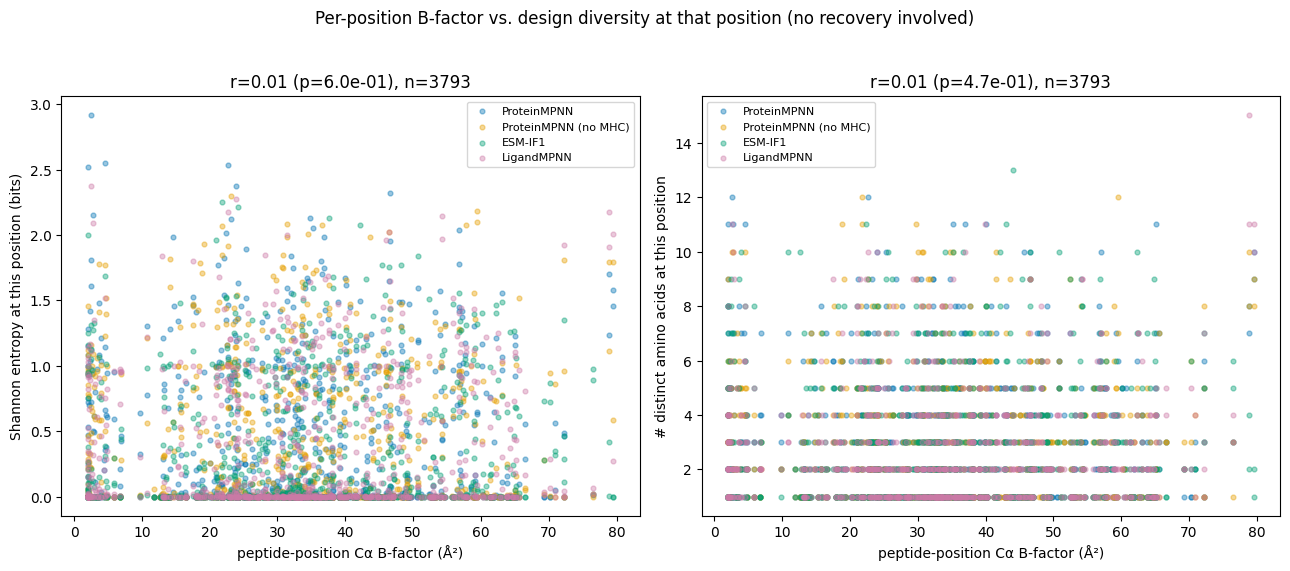

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_bfactor_vs_design_diversity.png


In [15]:
def peptide_bfactor_by_position(pdb):
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    vals, seen = {}, set()
    order = []
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] == "C" and line[12:16].strip() == "CA":
                resnum = line[22:27]
                if resnum in seen:
                    continue
                seen.add(resnum)
                order.append(float(line[60:66]))
    return order  # 1-indexed by position via enumerate below

def shannon_entropy(counts):
    counts = np.array(counts, dtype=float)
    counts = counts[counts > 0]
    p = counts / counts.sum()
    return -(p * np.log2(p)).sum()

pos_records = []
for pdb in STRUCTS:
    bfac_by_pos = peptide_bfactor_by_position(pdb)
    length = int(lengths[pdb])
    for cond in CONDITIONS:
        df = designs[(pdb, cond)]
        for model in MODELS:
            peps = df.loc[df.model == model, "peptide"].tolist()
            if not peps:
                continue
            for pos in range(length):
                col = [p[pos] for p in peps]
                counts = pd.Series(col).value_counts()
                entropy = shannon_entropy(counts.values)
                pos_records.append({"pdb": pdb, "condition": cond, "model": model, "position": pos + 1,
                                    "bfactor": bfac_by_pos[pos], "n_unique_aa": counts.shape[0],
                                    "entropy": entropy})

pos_df = pd.DataFrame(pos_records)
r_ent, p_ent = pearsonr(pos_df["bfactor"], pos_df["entropy"])
r_n, p_n = pearsonr(pos_df["bfactor"], pos_df["n_unique_aa"])
print(f"per-position B-factor vs. entropy: r={r_ent:.3f}, p={p_ent:.2e}, n={len(pos_df)}")
print(f"per-position B-factor vs. n_unique_aa: r={r_n:.3f}, p={p_n:.2e}, n={len(pos_df)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, ycol, ylabel, r, p in [(axes[0], "entropy", "Shannon entropy at this position (bits)", r_ent, p_ent),
                                (axes[1], "n_unique_aa", "# distinct amino acids at this position", r_n, p_n)]:
    for model in MODELS:
        sub = pos_df[pos_df.model == model]
        ax.scatter(sub["bfactor"], sub[ycol], s=12, alpha=0.4, color=MODEL_COLOR[model],
                   label=MODEL_LABEL[model])
    ax.set_xlabel("peptide-position Cα B-factor (Å²)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"r={r:.2f} (p={p:.1e}), n={len(pos_df)}")
    ax.legend(fontsize=8)
fig.suptitle("Per-position B-factor vs. design diversity at that position (no recovery involved)", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_bfactor_vs_design_diversity.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 8. Per-structure design enrichment logos, one grid per model (4x5, all 20 PDBs)

Same enrichment/bits convention as Section 2, but un-pooled: one logo per structure (not merged by
peptide length), so all twenty crystals are visible individually, one grid per model. Structures are
ordered first by native peptide (so the replicate groups -- GILGFVFTL and SLLMWITQC -- sit next to
each other) and then by resolution within a peptide group (best to worst), rather than the arbitrary
panel order used elsewhere.

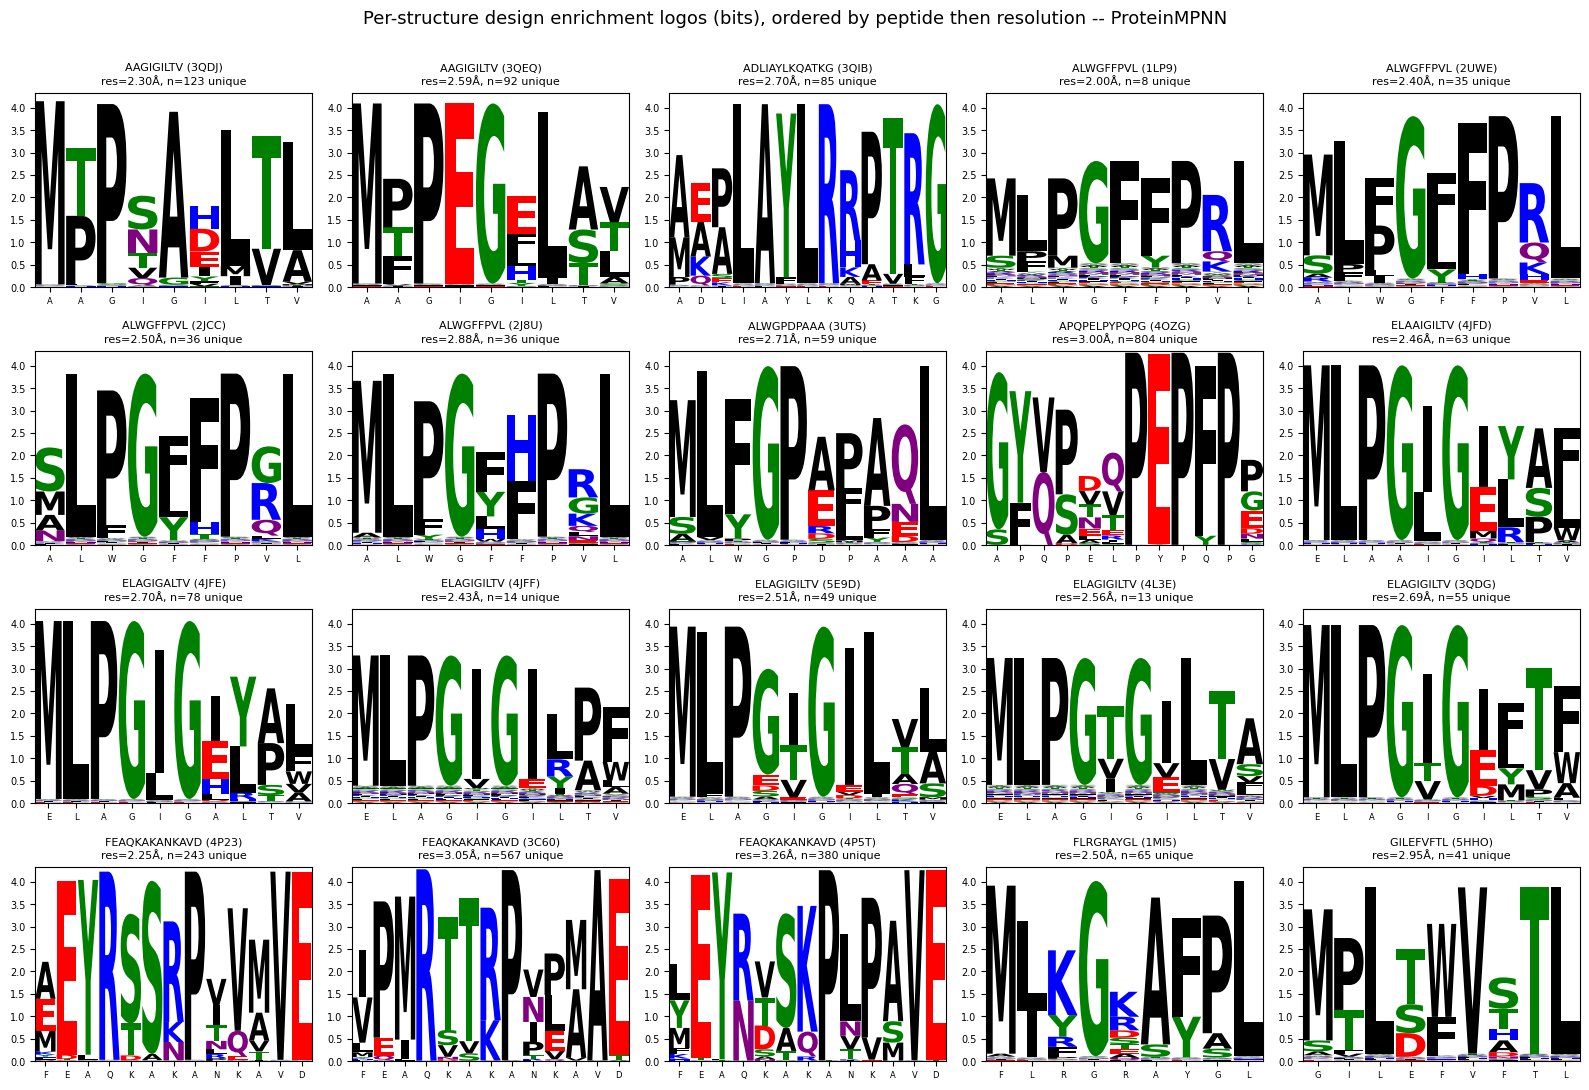

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logo_grid_vanilla.png


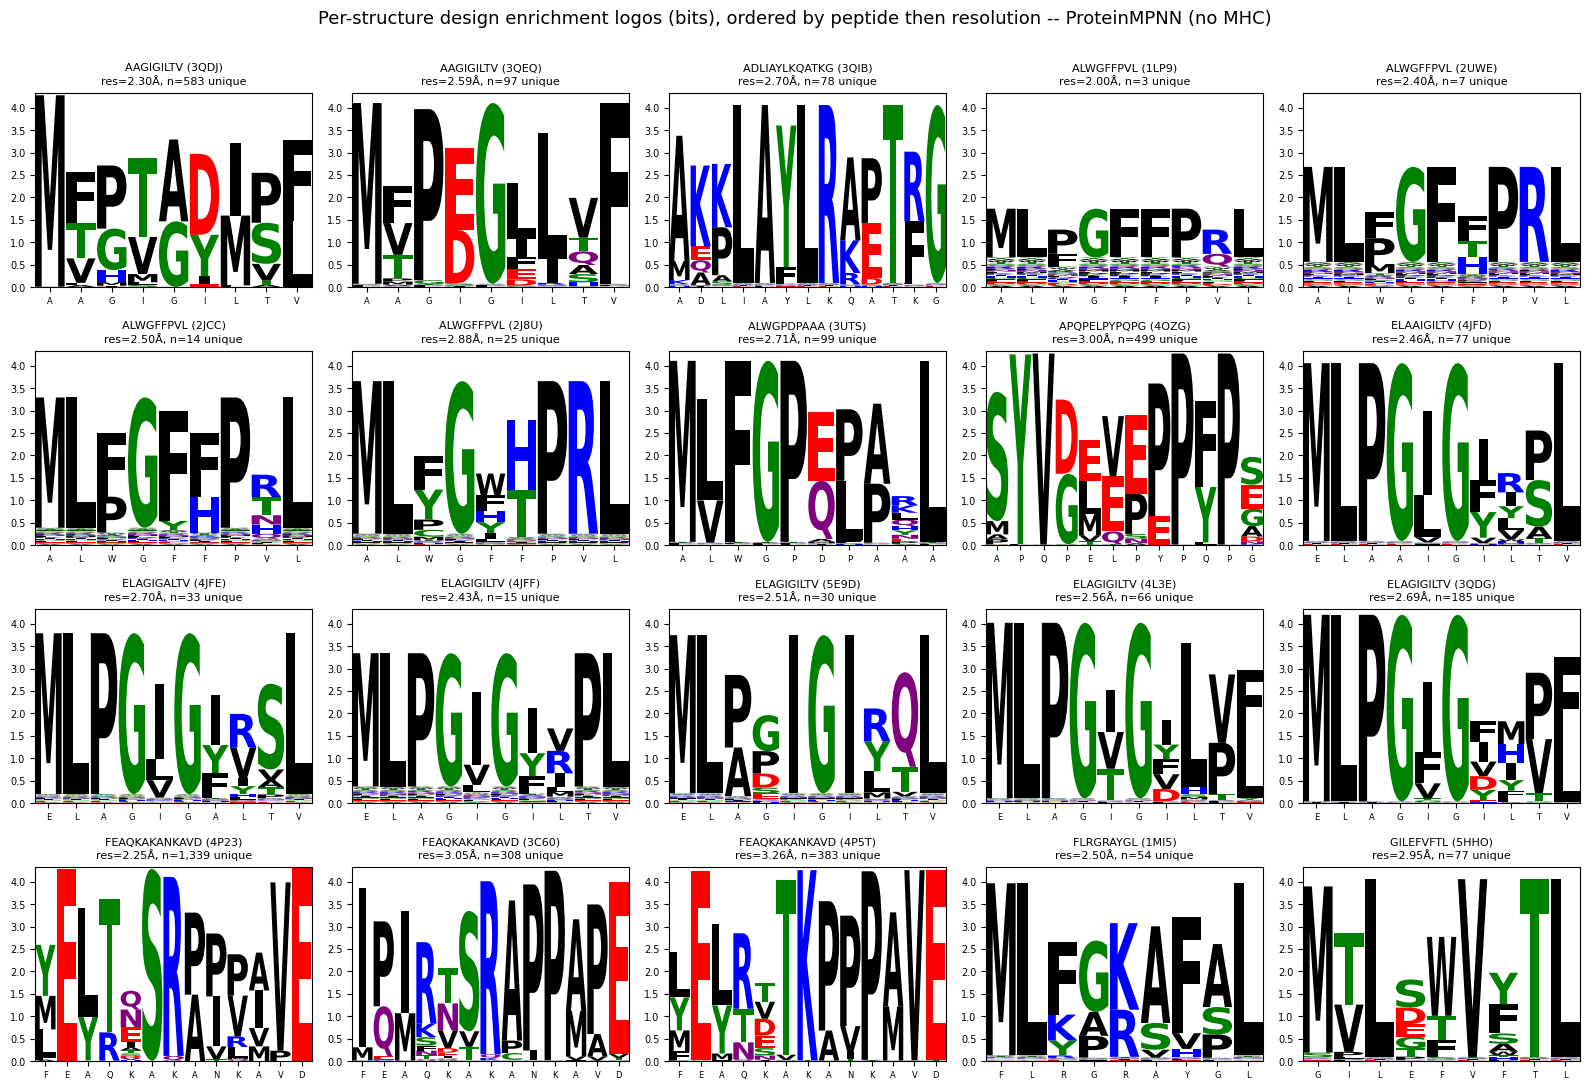

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logo_grid_noMHC.png


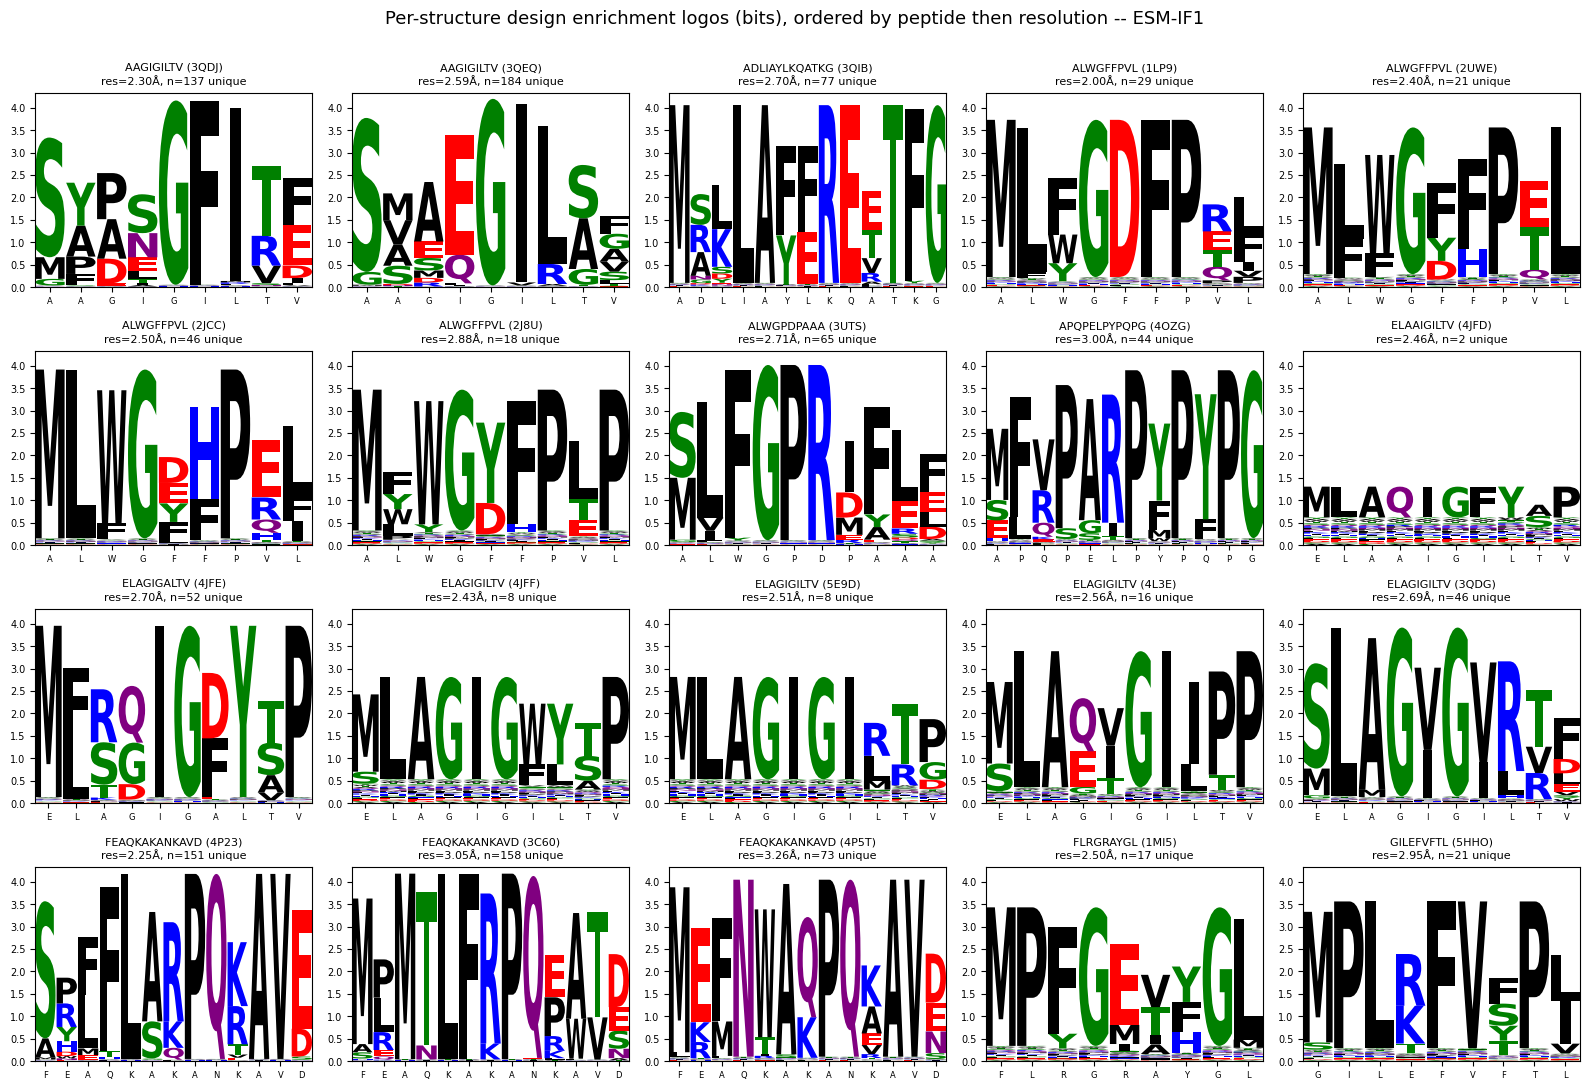

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logo_grid_ESM-IF1.png


/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/logomaker/src/Logo.py:1001: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])
/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/logomaker/src/Logo.py:1001: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])
/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/logomaker/src/Logo.py:1001: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])
/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/logomaker/src/Logo.py:1001: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])


/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/logomaker/src/Logo.py:1001: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])


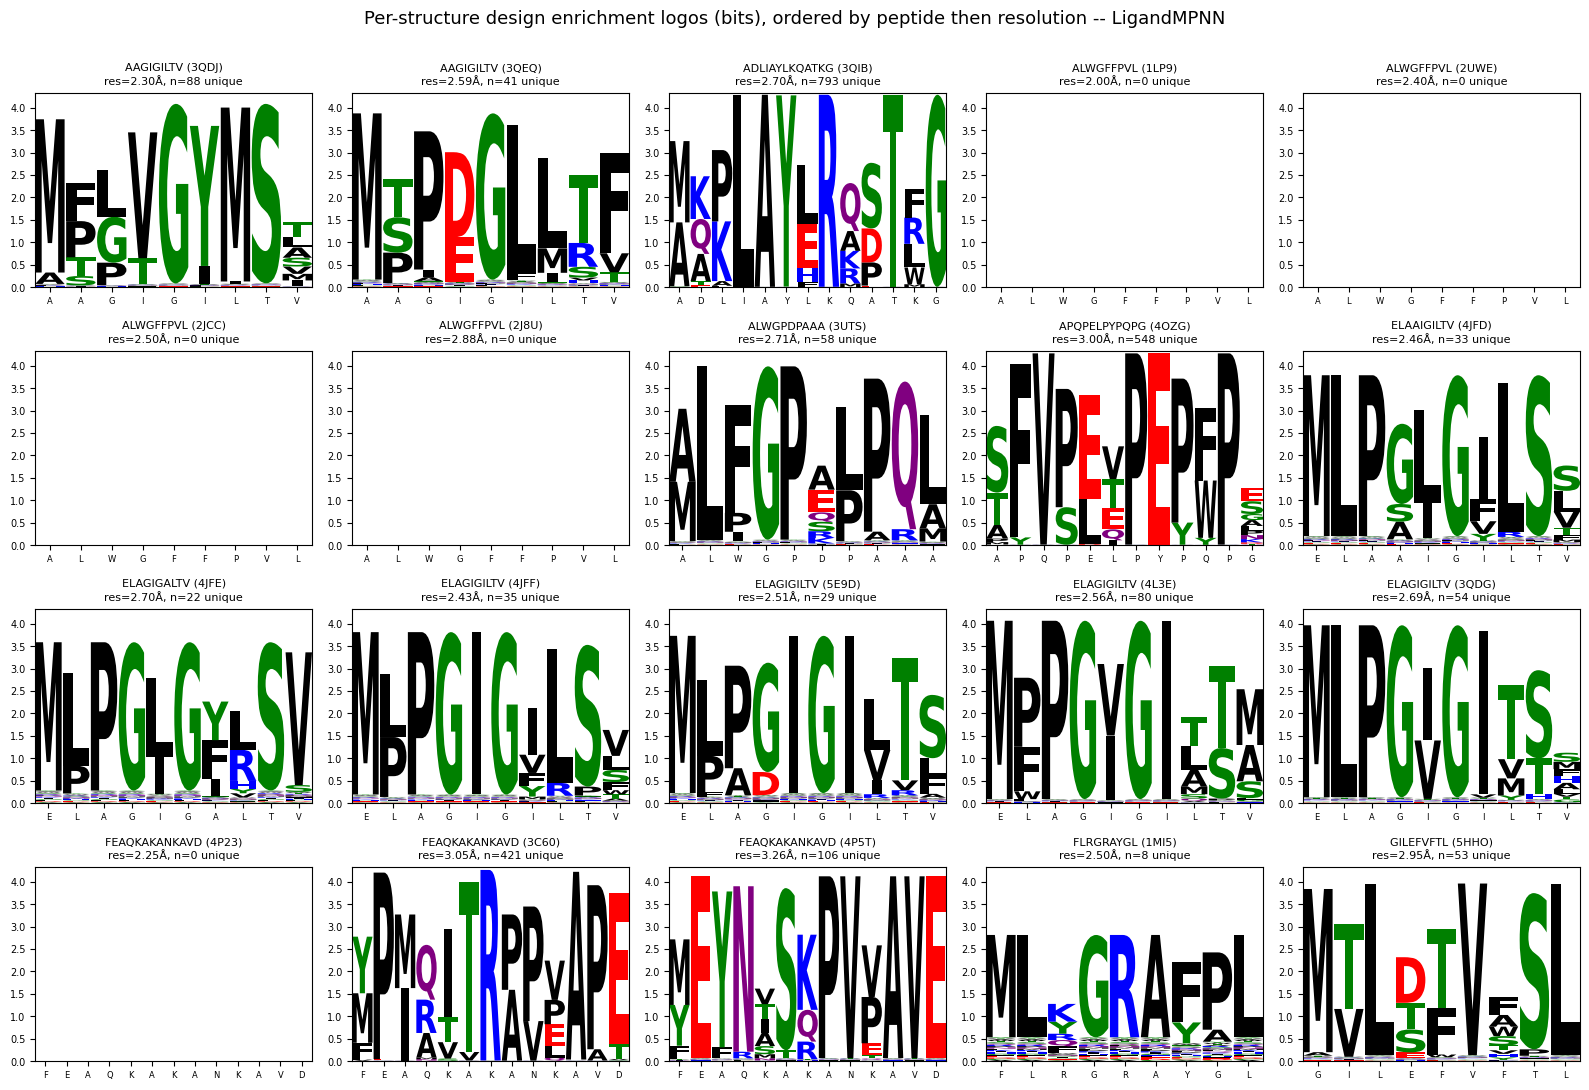

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logo_grid_LigandMPNN.png


In [16]:
def per_structure_design_logo_grid(cond, filename, suptitle):
    order = sorted(STRUCTS, key=lambda pdb: (natives[pdb], resolution[pdb]))
    n_rows, n_cols = 4, 5
    for model in MODELS:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.7 * n_rows))
        axes = axes.flatten()
        for ax, pdb in zip(axes, order):
            length = int(lengths[pdb])
            df = designs[(pdb, cond)]
            peps = sorted(set(df.loc[df.model == model, "peptide"].unique().tolist()))
            mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
            for pep in peps:
                if len(pep) != length:
                    continue
                for pos, aa in enumerate(pep, start=1):
                    if aa in AA:
                        mat.loc[pos, aa] += 1.0
            info_mat = logomaker.transform_matrix(mat, from_type="counts", to_type="information",
                                                  pseudocount=0.1)
            logomaker.Logo(info_mat, ax=ax, color_scheme="chemistry")
            ax.set_ylim(0, np.log2(len(AA)))
            ax.set_xticks(range(1, length + 1))
            ax.set_xticklabels(list(natives[pdb]), fontsize=6)
            ax.tick_params(axis="y", labelsize=7)
            ax.set_title(f"{natives[pdb]} ({pdb})\nres={resolution[pdb]:.2f}Å, n={len(peps):,} unique",
                        fontsize=8)
        fig.suptitle(f"{suptitle} -- {MODEL_LABEL[model]}", y=1.005, fontsize=13)
        fig.tight_layout()
        out = FIG_DIR / f"{filename}_{model}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"wrote {out}")

per_structure_design_logo_grid("full", "fig_panel2_design_logo_grid",
                               "Per-structure design enrichment logos (bits), ordered by peptide then resolution")

### Same grid, all four models' designs pooled together (one logo per structure, not per model)

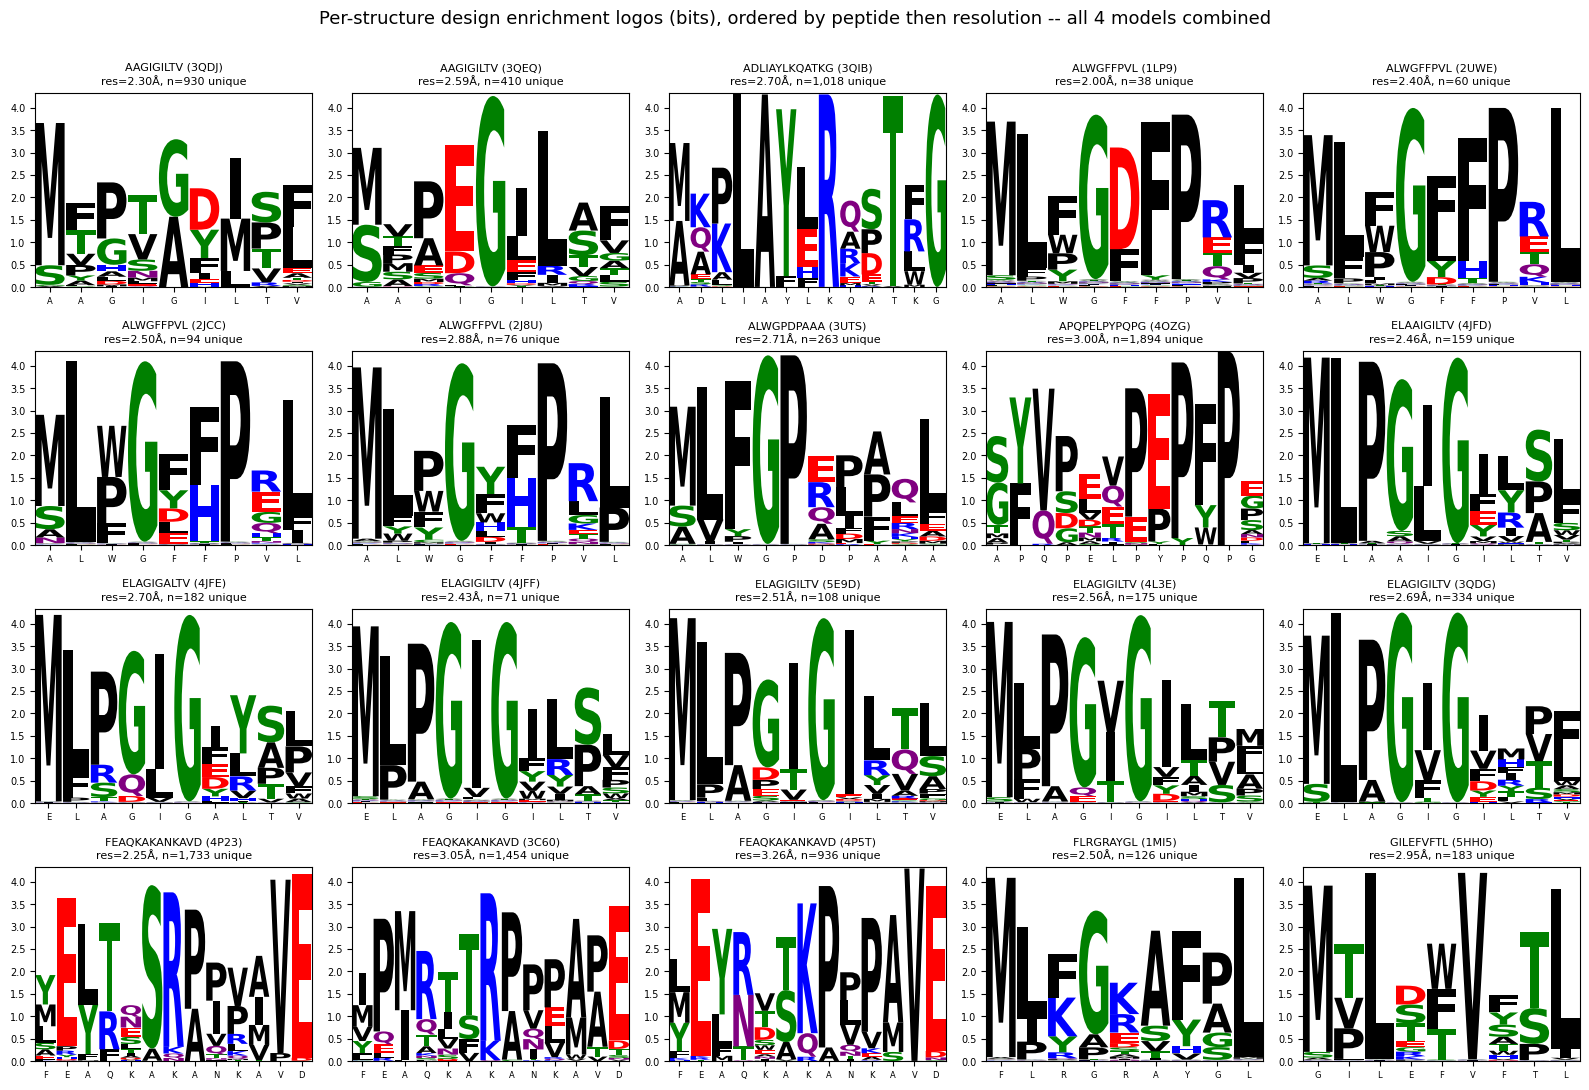

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_design_logo_grid_pooled.png


In [17]:
def pooled_per_structure_design_logo_grid(cond, filename, suptitle):
    order = sorted(STRUCTS, key=lambda pdb: (natives[pdb], resolution[pdb]))
    n_rows, n_cols = 4, 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.7 * n_rows))
    axes = axes.flatten()
    for ax, pdb in zip(axes, order):
        length = int(lengths[pdb])
        df = designs[(pdb, cond)]
        peps = sorted(set(df["peptide"].unique().tolist()))  # pooled across all 4 models
        mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
        for pep in peps:
            if len(pep) != length:
                continue
            for pos, aa in enumerate(pep, start=1):
                if aa in AA:
                    mat.loc[pos, aa] += 1.0
        info_mat = logomaker.transform_matrix(mat, from_type="counts", to_type="information",
                                              pseudocount=0.1)
        logomaker.Logo(info_mat, ax=ax, color_scheme="chemistry")
        ax.set_ylim(0, np.log2(len(AA)))
        ax.set_xticks(range(1, length + 1))
        ax.set_xticklabels(list(natives[pdb]), fontsize=6)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_title(f"{natives[pdb]} ({pdb})\nres={resolution[pdb]:.2f}Å, n={len(peps):,} unique",
                    fontsize=8)
    fig.suptitle(f"{suptitle} -- all 4 models combined", y=1.005, fontsize=13)
    fig.tight_layout()
    out = FIG_DIR / f"{filename}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

pooled_per_structure_design_logo_grid("full", "fig_panel2_design_logo_grid_pooled",
                                      "Per-structure design enrichment logos (bits), ordered by peptide then resolution")

## 9. Does low entropy mean more contacts, or specifically matter for TCR recognition?

Section 5 found no real correlation between entropy and *total* atom-contact count (TCR+MHC combined).
That total conflates two very different kinds of contact: backbone-mediated MHC anchoring (structurally
required but often side-chain-agnostic -- pocket A/P1-like) and side-chain-specific TCR contact (the
part that actually determines antigen recognition). Splitting the two back out asks the sharper
question directly: is a predictable position (low entropy) predictable because it's an MHC anchor, or
because the TCR itself is reading that side chain? TCR contact is only computed with a TCR physically
present, so this uses the pMHC+TCR condition only -- comparing against mhconly entropy here would ask
whether TCR contact predicts a diversity value from designs that never saw a TCR, which is circular.

A second question uses recovery (fraction of pooled designs matching the native amino acid at that
position): low entropy could mean the models *converge on the right answer* (confidently correct) or
*converge on the wrong one* (confidently wrong, as seen before with RFdiffusion's backbone designs) --
entropy alone can't distinguish these, recovery can.

**Caveat, unchanged from before:** all of this -- contacts, distances, B-factor, entropy, recovery --
comes from static geometry in one crystallographic snapshot (or a fixed model output distribution).
None of it is a binding-affinity estimate. Real affinity/energetics would need something like
SKEMPI-style experimental $\Delta\Delta G$, MD free-energy calculations, or an actual deep mutational
scan -- not a proxy this notebook can produce.

entropy vs. TCR contacts (pMHC+TCR): r=0.001, p=9.80e-01, n=483
entropy vs. MHC contacts (pMHC+TCR): r=-0.030, p=5.16e-01, n=483


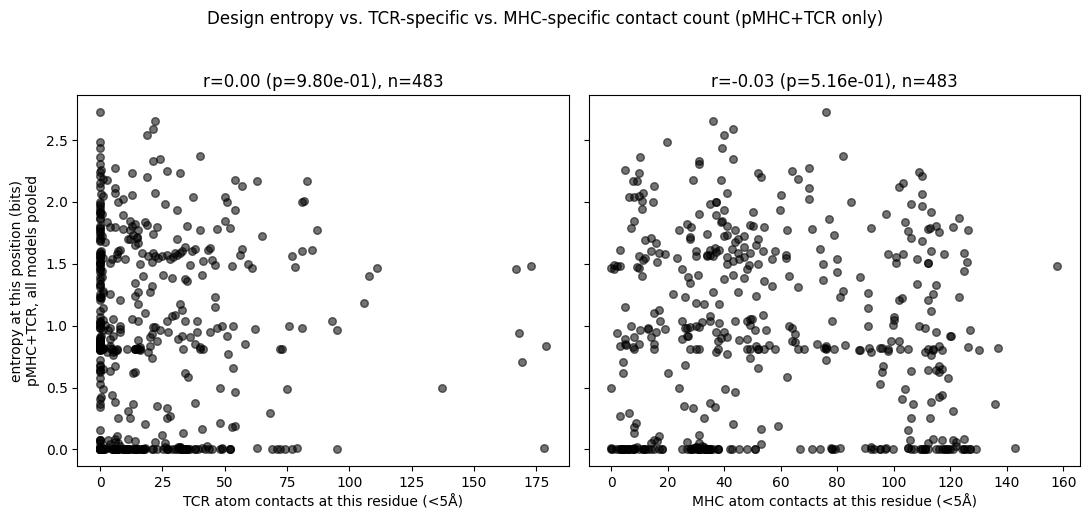

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_diversity_entropy_vs_tcr_mhc_contacts.png


In [18]:
def position_recovery_records(cond):
    records = []
    for pdb in STRUCTS:
        length = int(lengths[pdb])
        native = natives[pdb]
        peps = designs[(pdb, cond)]["peptide"].tolist()  # raw, all models pooled
        if not peps:
            continue
        for pos in range(length):
            recovery = float(np.mean([p[pos] == native[pos] for p in peps]))
            records.append({"pdb": pdb, "position": pos + 1, "condition": cond, "recovery": recovery})
    return pd.DataFrame(records)

recovery_pooled_df = pd.concat([position_recovery_records(cond) for cond in CONDITIONS], ignore_index=True)
residue_pooled_df = residue_pooled_df.merge(recovery_pooled_df, on=["pdb", "position", "condition"])

sub_full = residue_pooled_df[residue_pooled_df.condition == "full"]
r_tcr, p_tcr = pearsonr(sub_full["n_tcr_contacts"], sub_full["entropy"])
r_mhc, p_mhc = pearsonr(sub_full["n_mhc_contacts"], sub_full["entropy"])
print(f"entropy vs. TCR contacts (pMHC+TCR): r={r_tcr:.3f}, p={p_tcr:.2e}, n={len(sub_full)}")
print(f"entropy vs. MHC contacts (pMHC+TCR): r={r_mhc:.3f}, p={p_mhc:.2e}, n={len(sub_full)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
rng = np.random.RandomState(0)
for ax, xcol, xlabel, r, p in [(axes[0], "n_tcr_contacts", "TCR atom contacts at this residue (<5Å)", r_tcr, p_tcr),
                                (axes[1], "n_mhc_contacts", "MHC atom contacts at this residue (<5Å)", r_mhc, p_mhc)]:
    jitter = rng.uniform(-0.15, 0.15, size=len(sub_full))
    ax.scatter(sub_full[xcol] + jitter, sub_full["entropy"], alpha=0.55, s=30, color="black")
    ax.set_xlabel(xlabel)
    ax.set_title(f"r={r:.2f} (p={p:.2e}), n={len(sub_full)}")
axes[0].set_ylabel("entropy at this position (bits)\npMHC+TCR, all models pooled")
fig.suptitle("Design entropy vs. TCR-specific vs. MHC-specific contact count (pMHC+TCR only)", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_diversity_entropy_vs_tcr_mhc_contacts.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Low entropy: confidently correct, or confidently wrong? Colored by Cα B-factor

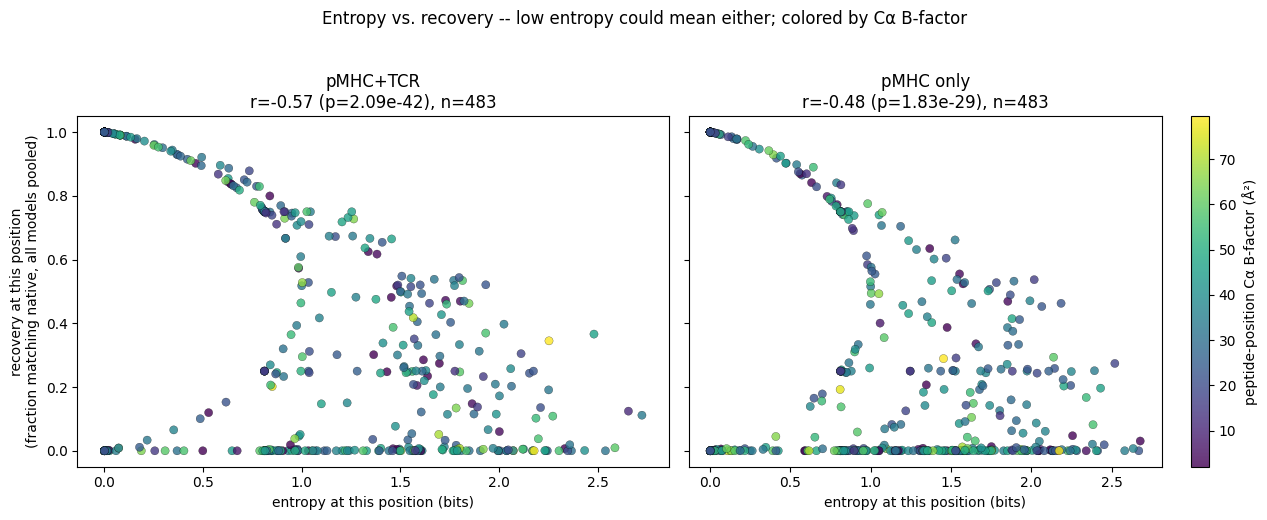

wrote /home/ubuntu/if-mhc/figures/fig_panel2_design_presentation/fig_panel2_entropy_vs_recovery_by_bfactor.png
entropy vs. recovery (pMHC+TCR): r=-0.567, p=2.09e-42
recovery vs. TCR contacts (pMHC+TCR): r=0.085, p=6.12e-02
recovery vs. MHC contacts (pMHC+TCR): r=-0.169, p=1.96e-04


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    sub = residue_pooled_df[residue_pooled_df.condition == cond]
    sc = ax.scatter(sub["entropy"], sub["recovery"], c=sub["ca_bfactor"], cmap="viridis",
                    s=35, alpha=0.8, edgecolor="black", linewidth=0.2)
    r, p = pearsonr(sub["entropy"], sub["recovery"])
    ax.set_xlabel("entropy at this position (bits)")
    ax.set_title(f"{COND_LABEL[cond]}\nr={r:.2f} (p={p:.2e}), n={len(sub)}")
axes[0].set_ylabel("recovery at this position\n(fraction matching native, all models pooled)")
fig.colorbar(sc, ax=axes[1], label="peptide-position Cα B-factor (Å²)")
fig.suptitle("Entropy vs. recovery -- low entropy could mean either; colored by Cα B-factor", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel2_entropy_vs_recovery_by_bfactor.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

r_rec_ent_full, p_rec_ent_full = pearsonr(residue_pooled_df.loc[residue_pooled_df.condition == "full", "entropy"],
                                          residue_pooled_df.loc[residue_pooled_df.condition == "full", "recovery"])
r_rec_tcr, p_rec_tcr = pearsonr(sub_full["n_tcr_contacts"], sub_full["recovery"])
r_rec_mhc, p_rec_mhc = pearsonr(sub_full["n_mhc_contacts"], sub_full["recovery"])
print(f"entropy vs. recovery (pMHC+TCR): r={r_rec_ent_full:.3f}, p={p_rec_ent_full:.2e}")
print(f"recovery vs. TCR contacts (pMHC+TCR): r={r_rec_tcr:.3f}, p={p_rec_tcr:.2e}")
print(f"recovery vs. MHC contacts (pMHC+TCR): r={r_rec_mhc:.3f}, p={p_rec_mhc:.2e}")